# HealthPlus US Member Segmentation & Retention Analysis

## Business Question:
#### Which HealthPlus members are most likely to lapse their health insurance, what drives their decision to leave, and which targeted retention interventions by member segment will generate the highest return on retention investment?

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import chi2_contingency, ttest_ind, f_oneway
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, roc_curve, classification_report)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except:
    HAS_XGB = False

print('Imports done')

Imports done


In [2]:
# Load data
file_path = r"C:\Users\Angelin\OneDrive - The University of Colorado Denver\Angelin Tisha Classes\BANA 6610 Statistics for BA\Final Projects\Data\HealthPlus_US_MemberChurn_2025.csv"

df_raw = pd.read_csv(file_path)

print("Raw dataset shape:", df_raw.shape)
df = df_raw.copy()
display(df.head())

# Make results reproducible
np.random.seed(42)

Raw dataset shape: (501500, 47)


,customer_id,as_of_date,policy_start_date,renewal_date,state,us_region,age,education_level,employment_status,annual_income,...,complaint_resolution_days,quote_requested_flag,coverage_downgrade_flag,digital_engagement_score,nps_score,customer_lifetime_value,churn_flag,churn_type,rfm_score,rfm_segment
0,1,2025-12-31,2024-05-02,2026-06-01,Colorado,West,61,Some College,Unemployed,21761.0,...,0,0,0,40.6,No Response,3772.61,0,No Churn,7,Potential Loyalists
1,2,2025-12-31,2025-11-01,2026-09-01,Georgia,South,28,Bachelor's,Unemployed,23210.0,...,0,0,0,60.8,7,3270.43,0,No Churn,6,Potential Loyalists
2,3,2025-12-31,2024-12-31,2026-04-01,Oregon,West,67,Some College,Retired,37808.0,...,0,0,0,43.7,7,6114.87,1,Price Sensitivity,8,Loyal Customers
3,4,2025-12-31,2020-04-01,2026-08-01,Indiana,Midwest,54,NaN,Full-time,48578.0,...,0,0,0,26.9,No Response,7696.65,1,Other/Unknown,12,Champions
4,5,2025-12-31,2025-01-31,2026-11-01,Texas,South,67,Bachelor's,Retired,23474.0,...,0,0,0,26.2,No Response,7317.83,0,No Churn,8,Loyal Customers


## DATA CLEANING

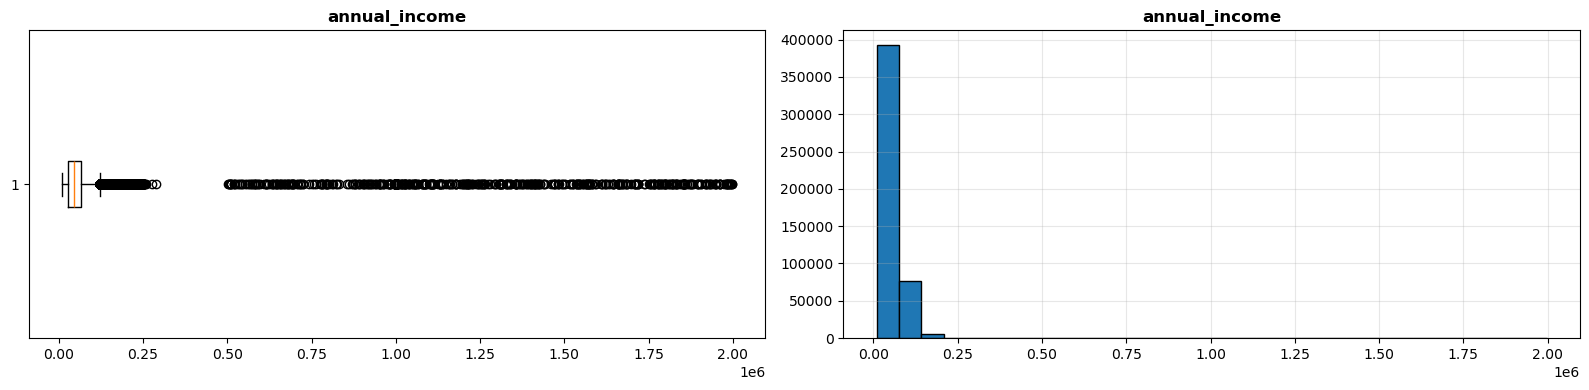

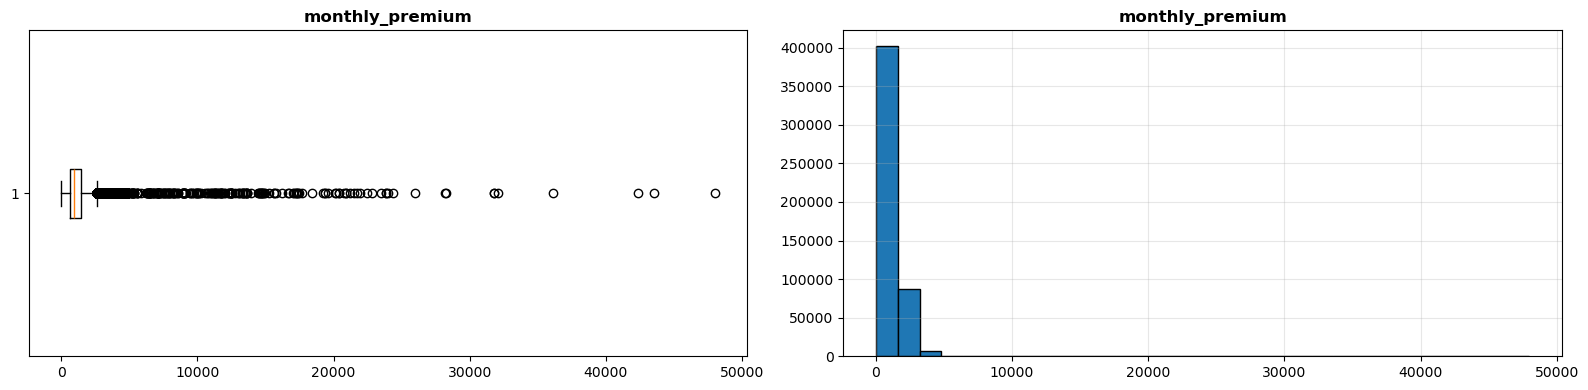

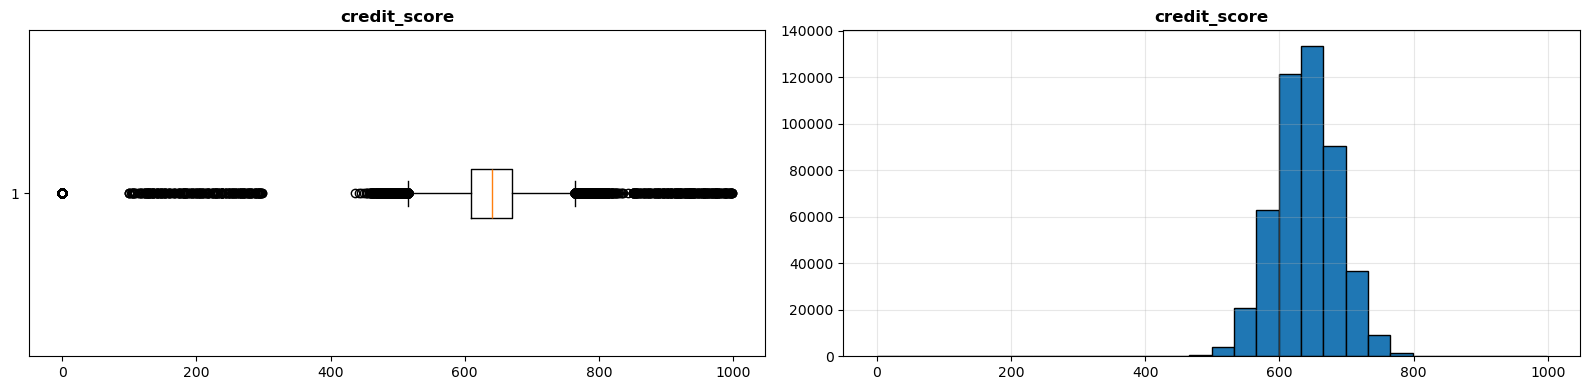

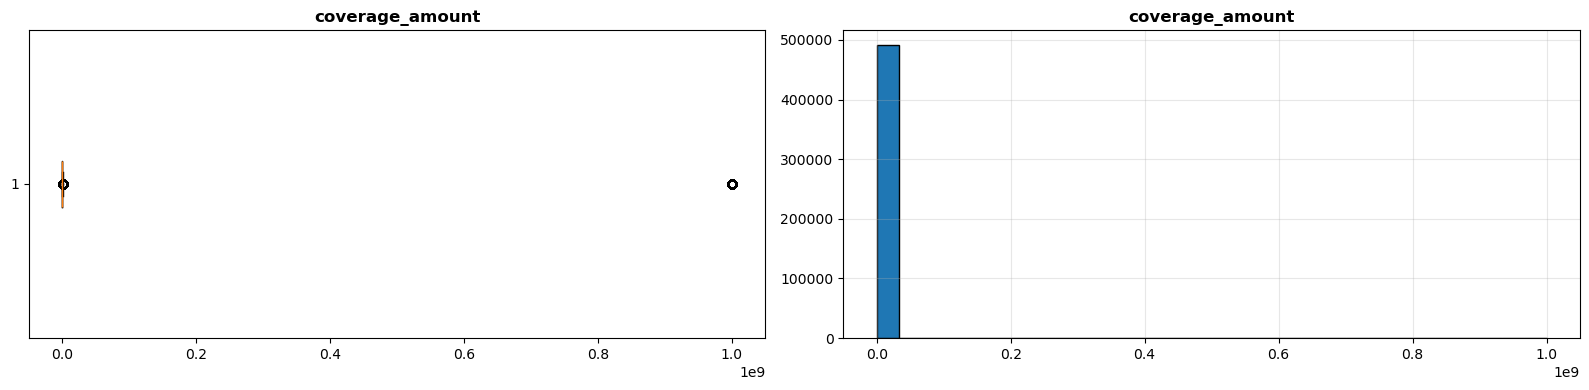

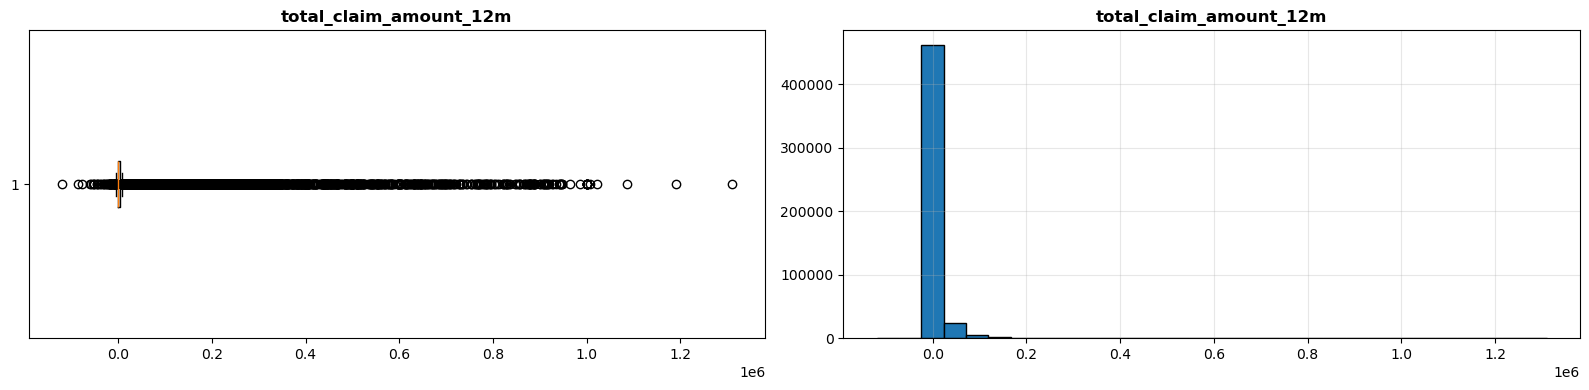

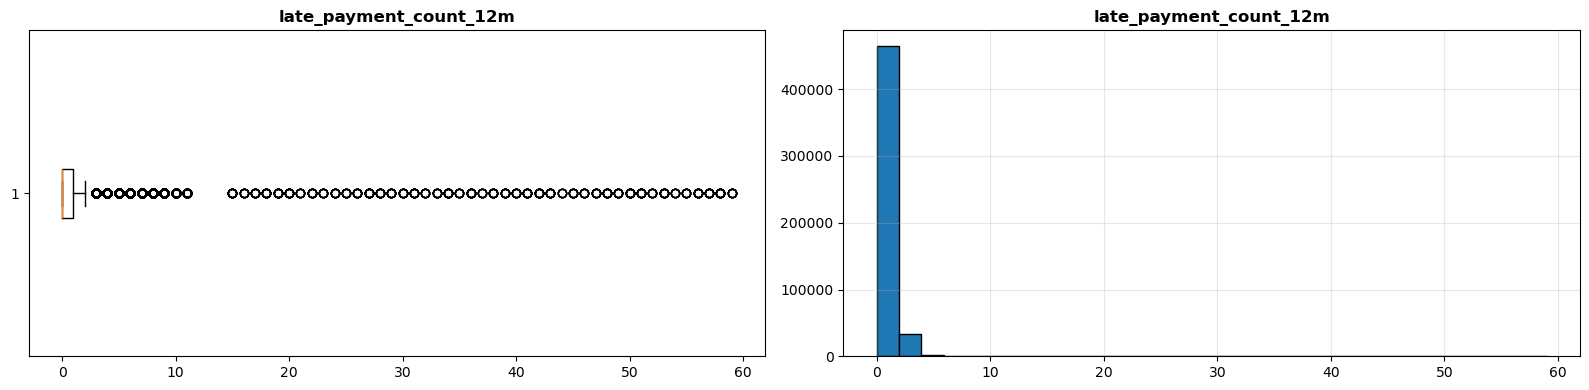

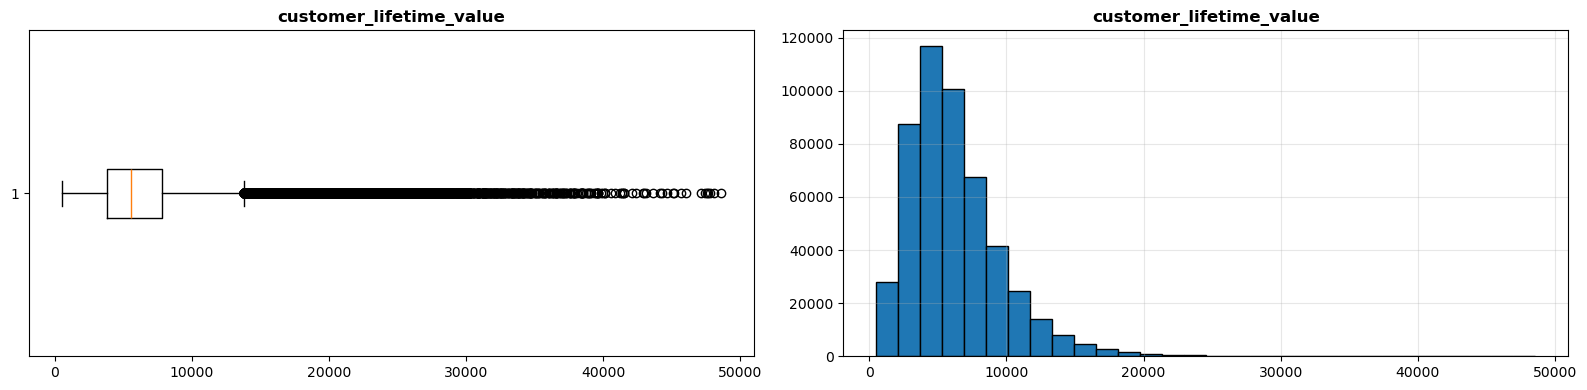

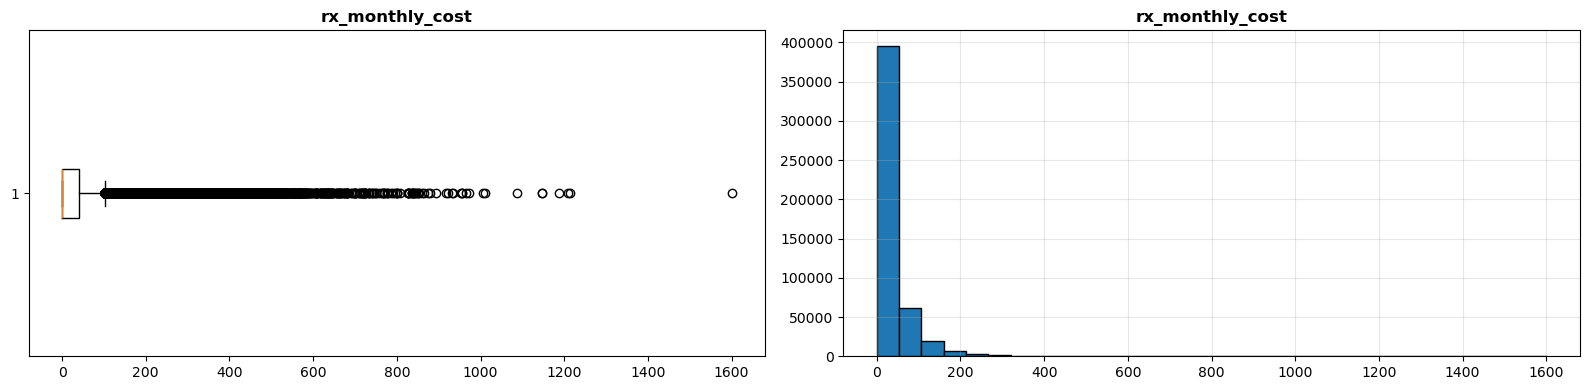

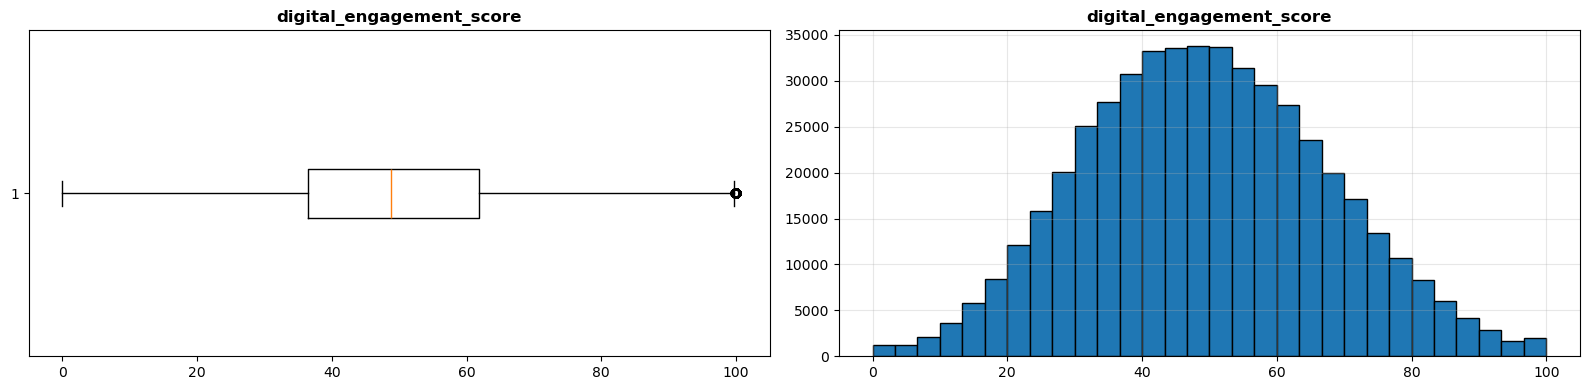

In [3]:
# DETECT OUTLIERS

num_cols = ['annual_income', 'monthly_premium', 'credit_score', 'coverage_amount', 'total_claim_amount_12m', 'late_payment_count_12m', 'customer_lifetime_value', 'rx_monthly_cost', 'digital_engagement_score']

# Method 1: Visual Inspection: Boxplots and Histograms
for col in num_cols:
    x = df[col]

    fig, axes = plt.subplots(1, 2, figsize=(16, 4))

    # Boxplot
    axes[0].boxplot(x.dropna(), vert=False)
    axes[0].set_title(col, fontweight='bold')

    # Histogram
    axes[1].hist(x, bins=30, edgecolor="black")
    axes[1].set_title(col, fontweight='bold')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()    

In [4]:
# Method 2: Descriptive Statistics
# Five-number summary + percentiles for every numeric column
desc = df[num_cols].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])
print(desc.round(2).T.to_string())

                             count       mean          std        min        1%        5%        25%        50%        75%         95%         99%           max
annual_income             476480.0   52732.85     57727.95   10000.00  10000.00  13969.00   28850.00   44457.00   66248.00   108196.15   153148.42  1.996601e+06
monthly_premium           497493.0    1116.73       735.95       0.01    205.76    316.93     626.74     955.19    1427.04     2450.88     3457.02  4.800000e+04
credit_score              481471.0     639.28        49.41       0.00    531.00    564.00     609.00     640.00     671.00      715.00      746.00  9.980000e+02
coverage_amount           492474.0  932334.50  22563686.76       0.00  57017.65  86779.03  182251.34  290421.07  495796.70  1250054.13  1857241.26  1.000000e+09
total_claim_amount_12m    493974.0    6331.96     27037.86 -119445.14      0.00      0.00       0.00       0.00    3214.26    29945.76    94544.36  1.309727e+06
late_payment_count_12m    501500.0

In [5]:
# Method 3: IQR Method
outlier_summary = []

for col in num_cols:
    s = df[col].dropna()
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_low  = (s < lower).sum()
    n_high = (s > upper).sum()
    n_out  = n_low + n_high
    
    outlier_summary.append({
        'Column':     col,
        'Q1':         round(Q1, 2),
        'Q3':         round(Q3, 2),
        'IQR':        round(IQR, 2),
        'Lower Fence':round(lower, 2),
        'Upper Fence':round(upper, 2),
        'Below Fence':n_low,
        'Above Fence':n_high,
        'Total Outliers': n_out,
        'Outlier %':  round(n_out / len(s) * 100, 2)
    })

iqr_df = pd.DataFrame(outlier_summary)
print(iqr_df[iqr_df['Total Outliers'] > 0].to_string(index=False))

                  Column        Q1        Q3       IQR  Lower Fence  Upper Fence  Below Fence  Above Fence  Total Outliers  Outlier %
           annual_income  28850.00  66248.00  37398.00    -27247.00    122345.00            0        13890           13890       2.92
         monthly_premium    626.74   1427.04    800.30      -573.71      2627.49            0        18789           18789       3.78
            credit_score    609.00    671.00     62.00       516.00       764.00         2106         1719            3825       0.79
         coverage_amount 182251.34 495796.70 313545.36   -288066.70    966114.73            0        38711           38711       7.86
  total_claim_amount_12m      0.00   3214.26   3214.26     -4821.39      8035.64           50        79398           79448      16.08
  late_payment_count_12m      0.00      1.00      1.00        -1.50         2.50            0         9072            9072       1.81
 customer_lifetime_value   3843.50   7838.21   3994.71     -21

In [6]:
# Method 4: Z-Score Method

zscore_summary = []

for col in num_cols:
    s = df[col].dropna()
    z = np.abs(stats.zscore(s))
    n_out = (z > 3).sum()
    
    zscore_summary.append({
        'Column':   col,
        'Mean':     round(s.mean(), 2),
        'Std Dev':  round(s.std(), 2),
        'Min':      round(s.min(), 2),
        'Max':      round(s.max(), 2),
        '|z|>3 Count': n_out,
        '|z|>3 %':  round(n_out / len(s) * 100, 2)
    })

z_df = pd.DataFrame(zscore_summary)
print(z_df[z_df['|z|>3 Count'] > 0].to_string(index=False))

                 Column      Mean     Std Dev        Min          Max  |z|>3 Count  |z|>3 %
          annual_income  52732.85    57727.95   10000.00   1996601.00          985     0.21
        monthly_premium   1116.73      735.95       0.01     48000.00         6170     1.24
           credit_score    639.28       49.41       0.00       998.00         1251     0.26
        coverage_amount 932334.50 22563686.76       0.00 999999999.00          251     0.05
 total_claim_amount_12m   6331.96    27037.86 -119445.14   1309727.31         5632     1.14
 late_payment_count_12m      0.41        1.33       0.00        59.00         1544     0.31
customer_lifetime_value   6233.53     3473.80     500.00     48575.15         7109     1.42
        rx_monthly_cost     28.65       50.12       0.00      1600.65         9247     1.89


In [7]:
# Method 5: Domain Bound Checks
# Define what's valid based on business/domain knowledge
domain_bounds = {
    'annual_income':            (0,       450_000),
    'credit_score':             (300,     850),
    'monthly_premium':          (85,      4_800),
    'coverage_amount':          (1_000,   2_000_000),
    'total_claim_amount_12m':   (0,       400_000),
    'late_payment_count_12m':   (0,       12),          # max 12 months
    'deductible':               (0,       8_500),
    'digital_engagement_score': (0,       100),          # it's a score 0-100
    'age':                      (18,      85),
    'customer_tenure_months':   (1,       180),
    'premium_change_pct':       (-0.5,    0.5),          # -50% to +50% realistic
}

print(f"{'Column':<35} {'Lower Bound':>12} {'Upper Bound':>12} {'Below':>8} {'Above':>8} {'Total':>8}")
print("-" * 90)
for col, (lo, hi) in domain_bounds.items():
    if col not in df.columns: continue
    s = pd.to_numeric(df[col], errors='coerce').dropna()
    n_low  = (s < lo).sum()
    n_high = (s > hi).sum()
    n_tot  = n_low + n_high
    if n_tot > 0:
        print(f"{col:<35} {lo:>12,} {hi:>12,} {n_low:>8,} {n_high:>8,} {n_tot:>8,}")

Column                               Lower Bound  Upper Bound    Below    Above    Total
------------------------------------------------------------------------------------------
annual_income                                  0      450,000        0      905      905
credit_score                                 300          850      500      250      750
monthly_premium                               85        4,800      250      207      457
coverage_amount                            1,000    2,000,000      250      251      501
total_claim_amount_12m                         0      400,000       68      440      508
late_payment_count_12m                         0           12        0      401      401


#### Key Findings — Outlier Detection

Five methods were applied to detect outliers across 9 numeric columns.
The table below summarises what each method found and what action is required.

| Column | Visual Inspection | Descriptive Stats | IQR | Z Score | Domain Bounds | Action Required |
|---|---|---|---|---|---|---|
| annual_income | Long right tail, extreme upper dots | Large gap between 99th pct and max | All outliers above upper fence | Fewer flagged than IQR — large std absorbs variation | Values exceed upper bound | Replace placeholder with NaN, impute by employment group, cap at 99th pct |
| monthly_premium | Extreme upper dots, histogram shows tiny spike near zero (system placeholder issue) | Max is ~14× the 99th percentile | All outliers above upper fence | Captures errors and some legitimate high premiums | Violations at both ends | Treat value below 10 as missing, impute by plan tier, cap at 99th pct |
| credit_score | Dots on both sides of boxplot | Narrow IQR but impossible min (0) and max (>850) | Tight fences flag both sides including legitimate scores | Most suitable method — near-normal distribution | 500 below FICO min, 250 above FICO max | Set zeros to NaN, impute by age band, clip to 300, 850 |
| coverage_amount | Single isolated extreme dot | Std vastly larger than mean — one value distorts everything | Oversensitive — flags legitimate high-coverage policies | Precisely isolates the sentinel values only | 250 zero values, 251 sentinel values | Treat both as missing, impute by policy type |
| total_claim_amount_12m | Spike at zero, dot below zero | Negative minimum, large max vs 99th pct gap | Unreliable — zero-inflation collapses IQR | Captures extreme claims and severe negatives | 68 negative, 440 above 400K | Apply abs() to negatives, retain high claims with flag |
| late_payment_count_12m | Extreme dots far above whisker | Max of 59 far exceeds the 12-month window maximum | Oversensitive — flags legitimate 3–12 payments | Threshold too low due to zero-inflation | 401 values above 12 | Cap at 12 |
| customer_lifetime_value | Moderate right skew, upper dots present | Max ~2.7× the 99th pct — moderate gap | Flags natural right tail, not errors | Flags genuine high-value members | No violations | No treatment — legitimate high-value members |
| rx_monthly_cost | Zero spike, right-skewed tail | Median is zero, mean pulled by tail | False positive — zero-inflation collapses IQR | Threshold too low due to zero-inflation | No violations | No treatment — zero-inflation artefact, not errors |
| digital_engagement_score | Clean symmetric distribution | Mean and median nearly identical, bounded 0–100 | Only flags scores at exact maximum of 100 | Zero values flagged — threshold above column maximum | No violations |  No treatment — cleanest column in the dataset |

In [8]:
# HANDLE OUTLIERS

# annual_income - placeholder 999999 -> treat as missing -> re-impute
df['annual_income'] = df['annual_income'].replace(999999, np.nan)
df['annual_income'] = df['annual_income'].fillna(
    df.groupby('employment_status')['annual_income'].transform('median'))
df['annual_income'] = df['annual_income'].fillna(df['annual_income'].median())

# annual_income - cap extreme values at 99th percentile
cap_income = df['annual_income'].quantile(0.99)
df['annual_income'] = df['annual_income'].clip(upper=cap_income)

# monthly premium - $0.01 placeholder -> treat as missing -> re-impute
df.loc[df['monthly_premium'] < 10, 'monthly_premium'] = np.nan
df['monthly_premium'] = df['monthly_premium'].fillna(
    df.groupby('plan_tier')['monthly_premium'].transform('median'))
df['monthly_premium'] = df['monthly_premium'].fillna(df['monthly_premium'].median())

# monthly_premium — cap x10 typos at 99th percentile
cap_premium = df['monthly_premium'].quantile(0.99)
df['monthly_premium'] = df['monthly_premium'].clip(upper=cap_premium)

# credit score - zero -> treat as missing -> re-impute
df['age_band'] = pd.cut(df['age'], bins=[17,24,34,44,54,64,74,90],
    labels=['18-24','25-34','35-44','45-54','55-64','65-74','75+'])
df.loc[df['credit_score'] == 0, 'credit_score'] = np.nan
df['credit_score'] = df['credit_score'].fillna(
    df.groupby('age_band', observed=True)['credit_score'].transform('median'))
df['credit_score'] = df['credit_score'].fillna(df['credit_score'].median())
df.drop(columns=['age_band'], inplace=True)

# credit_score — clip to valid FICO range [300, 850]
df['credit_score'] = df['credit_score'].clip(lower=300, upper=850)

# coverage_amount - $0 and $999,999,999 -> treat as missing -> re-impute
df.loc[(df['coverage_amount'] == 0) | 
       (df['coverage_amount'] == 999_999_999), 'coverage_amount'] = np.nan
df['coverage_amount'] = df['coverage_amount'].fillna(
    df.groupby('policy_type')['coverage_amount'].transform('median'))
df['coverage_amount'] = df['coverage_amount'].fillna(df['coverage_amount'].median())

# total_claim_amount_12m - negative values -> apply absolute value
df['total_claim_amount_12m'] = df['total_claim_amount_12m'].abs()

# total_claim_amount_12m - catastrophic claims -> add indicator flag
df['high_claim_flag'] = (df['total_claim_amount_12m'] > 400_000).astype(int)

# late_payment_count_12m - cap at 12 (max possible in 12-month window)
df['late_payment_count_12m'] = df['late_payment_count_12m'].clip(upper=12)

In [9]:
# DETECT MISSING VALUES
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Missing': missing, 'Pct': missing_pct})
miss_df = miss_df[miss_df.Missing > 0].sort_values('Pct', ascending=False)
print(miss_df)

                          Missing   Pct
nps_score                   35096  7.00
education_level             30082  6.00
employment_status           20217  4.03
digital_engagement_score    15044  3.00
rx_monthly_cost             12530  2.50
total_claim_amount_12m       7526  1.50
net_monthly_premium          4014  0.80
churn_type                     82  0.02


In [10]:
# HANDLE MISSING VALUES

# nps_score - 'No Response' category
df['nps_score'] = df['nps_score'].fillna('No Response')

# education_level - mode imputation
df['education_level'] = df['education_level'].fillna(df['education_level'].mode()[0])

# Fallback global median
df['annual_income'] = df['annual_income'].fillna(df['annual_income'].median())

# employment_status - mode imputation
df['employment_status'] = df['employment_status'].fillna(df['employment_status'].mode()[0])

# digital_engagement_score - median
df['digital_engagement_score'] = df['digital_engagement_score'].fillna(df['digital_engagement_score'].median())

# rx_monthly_cost - 0 (no prescription = no cost)
df['rx_monthly_cost'] = df['rx_monthly_cost'].fillna(0)

# coverage_amount - median by policy_type
df['coverage_amount'] = df['coverage_amount'].fillna(
    df.groupby('policy_type')['coverage_amount'].transform('median'))

# total_claim_amount_12m - 0 (no claims filed)
df['total_claim_amount_12m'] = df['total_claim_amount_12m'].fillna(0)

# monthly_premium - mean by plan_tier
df['monthly_premium'] = df['monthly_premium'].fillna(
    df.groupby('plan_tier')['monthly_premium'].transform('median'))
df['monthly_premium'] = df['monthly_premium'].fillna(df['monthly_premium'].median())

# net_monthly_premium - derive from monthly_premium - subsidy_amount_monthly
mask = df['net_monthly_premium'].isnull()
df.loc[mask, 'net_monthly_premium'] = (
    df.loc[mask, 'monthly_premium'] - df.loc[mask, 'subsidy_amount_monthly'].fillna(0)).round(2)

# churn_type
df['churn_type'] = df['churn_type'].fillna('Other/Unknown')


In [11]:
# STANDARDISE FORMAT INCONSISTENCIES

# State: map abbreviations and variants -> full name
state_map = {
    'AL':'Alabama', 'AK':'Alaska', 'AZ':'Arizona', 'AR':'Arkansas',
    'CA':'California', 'CO':'Colorado', 'CT':'Connecticut', 'DE':'Delaware',
    'DC':'District of Columbia', 'FL':'Florida', 'GA':'Georgia', 'HI':'Hawaii',
    'ID':'Idaho', 'IL':'Illinois', 'IN':'Indiana', 'IA':'Iowa', 'KS':'Kansas',
    'KY':'Kentucky', 'LA':'Louisiana', 'ME':'Maine', 'MD':'Maryland',
    'MA':'Massachusetts', 'MI':'Michigan', 'MN':'Minnesota', 'MS':'Mississippi',
    'MO':'Missouri', 'MT':'Montana', 'NE':'Nebraska', 'NV':'Nevada',
    'NH':'New Hampshire', 'NJ':'New Jersey', 'NM':'New Mexico', 'NY':'New York',
    'NC':'North Carolina', 'ND':'North Dakota', 'OH':'Ohio', 'OK':'Oklahoma',
    'OR':'Oregon', 'PA':'Pennsylvania', 'RI':'Rhode Island', 'SC':'South Carolina',
    'SD':'South Dakota', 'TN':'Tennessee', 'TX':'Texas', 'UT':'Utah',
    'VT':'Vermont', 'VA':'Virginia', 'WA':'Washington', 'WV':'West Virginia',
    'WI':'Wisconsin', 'WY':'Wyoming'
}

df['state'] = df['state'].str.strip().str.upper().map(state_map).fillna(df['state'].str.title())
print("Unique state after cleaning:", df['state'].nunique())

# plan_tier -> Bronze / Silver / Gold / Platinum
df['plan_tier'] = df['plan_tier'].str.strip().str.lower()

df['plan_tier'] = np.select(
    [
        df['plan_tier'].str.contains('bron|brnz'),
        df['plan_tier'].str.contains('silv|slvr'),
        df['plan_tier'].str.contains('gold|gld'),
        df['plan_tier'].str.contains('plat')
    ],
    ['Bronze', 'Silver', 'Gold', 'Platinum'],
    default=df['plan_tier'].str.title()
)
print("\nUnique plan tier after cleaning:", df['plan_tier'].nunique())
print("Unique plan tier values:", df['plan_tier'].unique())

# education_level -> 5 values (High School, Some College, Bachelor's, Master's, PhD/Professional)
df['education_level'] = df['education_level'].str.strip().str.lower()

df['education_level'] = np.select(
    [
        df['education_level'].str.contains(r'phd|ph\.d|doctor|jd|md|prof'),
        df['education_level'].str.contains(r'm\.sc|msc|master|\bms\b|m\.s'),
        df['education_level'].str.contains(r'b\.sc|bsc|bachelor|bach|\bbs\b|b\.s'),
        df['education_level'].str.contains(r'some|college|\bsc\b'),
        df['education_level'].str.contains(r'high|\bhs\b|h\.s')
    ],
    ['PhD/Professional', "Master's", "Bachelor's", 'Some College', 'High School'],
    default=df['education_level'].str.title()
)
print("\nUnique education level after cleaning:", df['education_level'].nunique())
print("Unique education values:", df['education_level'].unique())

# employment_status -> 6 values (Full-time, Part-time, Self-employed, Retired, Student, Unemployed)
df['employment_status'] = df['employment_status'].str.strip().str.lower()

df['employment_status'] = np.select(
    [
        df['employment_status'].str.contains('stu|std|student'),
        df['employment_status'].str.contains('full|ft'),
        df['employment_status'].str.contains('part|pt'),
        df['employment_status'].str.contains('self|se|freela|independent'),
        df['employment_status'].str.contains('ret'),
    	df['employment_status'].str.contains('unem|not|jobless|n/a')
    ],
    ['Student', 'Full-time', 'Part-time', 'Self-employed', 'Retired', 'Unemployed'],
    default=df['employment_status'].str.title()
)
print("\nUnique employment status after cleaning:", df['employment_status'].nunique())
print("Unique employment status values:", df['employment_status'].unique())

# payment_frequency -> Monthly / Quarterly / Annual
df['payment_frequency'] = df['payment_frequency'].str.strip().str.lower()

df['payment_frequency'] = np.select(
    [
        df['payment_frequency'].str.contains(r'mon|mo\.'),
        df['payment_frequency'].str.contains('q|quar|3'),
        df['payment_frequency'].str.contains('year|yr|annual')
    ],
    ['Monthly', 'Quarterly', 'Annual'],
    default=df['payment_frequency'].str.title()
)
print("\nUnique payment frequency after cleaning:", df['payment_frequency'].nunique())
print("Unique payment frequency values:", df['payment_frequency'].unique())

# churn_type -> 8 values (No Churn, Price Sensitivity, Competitive Switch, Claims Dispute, Service Dissatisfaction, Financial Hardship, Coverage Change, Other/Unknown)
df['churn_type'] = df['churn_type'].str.strip().str.lower()

df['churn_type'] = np.select(
    [
        df['churn_type'].str.contains('churn|active|retained'),
        df['churn_type'].str.contains('price|cost|sensitivity'),
        df['churn_type'].str.contains('compe|switch'),
	df['churn_type'].str.contains('claim|dispute'),
	df['churn_type'].str.contains('service|dissa.'),
	df['churn_type'].str.contains('finan|hardship'),
	df['churn_type'].str.contains('coverag|change'),
	df['churn_type'].str.contains('other|unknown|unspecified')
    ],
    ['No Churn', 'Price Sensitivity', 'Competitive Switch', 'Claims Dispute', 'Service Dissatisfaction', 'Financial Hardship', 'Coverage Change', 'Other/Unknown'],
    default=df['churn_type'].str.title()
)
print("\nUnique churn type after cleaning:", df['churn_type'].nunique())
print("Unique churn type values:", df['churn_type'].unique())

# policy_type -> 7 values (Health HMO, Health PPO, Medicaid Supplement, Medicare Supplement, Dental/Vision, Short-term, Life)
df['policy_type'] = df['policy_type'].str.strip().str.lower()

df['policy_type'] = np.select(
    [
        df['policy_type'].str.contains('hmo'),
        df['policy_type'].str.contains('ppo'),
        df['policy_type'].str.contains('medicaid|med-aid'),
        df['policy_type'].str.contains('medicare|medigap|med sup'),
        df['policy_type'].str.contains('dental|d/v'),
        df['policy_type'].str.contains('short|stm'),
        df['policy_type'].str.contains('life'),
    ],
    ['Health HMO', 'Health PPO', 'Medicaid Supplement', 
     'Medicare Supplement', 'Dental/Vision', 'Short-term', 'Life'],
    default=df['policy_type'].str.title()
)

print("\nUnique policy type after cleaning:", df['policy_type'].nunique())
print("Unique policy type values:", df['policy_type'].unique())

Unique state after cleaning: 51

Unique plan tier after cleaning: 4
Unique plan tier values: ['Bronze' 'Gold' 'Silver' 'Platinum']

Unique education level after cleaning: 5
Unique education values: ['Some College' "Bachelor's" 'High School' "Master's" 'PhD/Professional']

Unique employment status after cleaning: 6
Unique employment status values: ['Unemployed' 'Retired' 'Full-time' 'Part-time' 'Self-employed' 'Student']

Unique payment frequency after cleaning: 3
Unique payment frequency values: ['Monthly' 'Annual' 'Quarterly']

Unique churn type after cleaning: 8
Unique churn type values: ['No Churn' 'Price Sensitivity' 'Other/Unknown' 'Competitive Switch'
 'Coverage Change' 'Service Dissatisfaction' 'Financial Hardship'
 'Claims Dispute']

Unique policy type after cleaning: 7
Unique policy type values: ['Health PPO' 'Dental/Vision' 'Health HMO' 'Life' 'Medicare Supplement'
 'Short-term' 'Medicaid Supplement']


In [12]:
# REMOVE DUPLICATES
print("Rows before:", len(df))
print("Exact duplicates:", df.duplicated().sum())
print("Duplicate customer_ids:", df['customer_id'].duplicated().sum())

# Drop exact duplicate rows
df = df.drop_duplicates()

# Drop duplicate customer_id with fewer null
df['_null_count'] = df.isnull().sum(axis=1)
df = df.sort_values('_null_count').drop_duplicates(subset='customer_id', keep='first')
df = df.drop(columns=['_null_count'])

print("Rows after dropping duplicates:", len(df))
print("Remaining duplicates:", df.duplicated().sum())

Rows before: 501500
Exact duplicates: 292
Duplicate customer_ids: 1500
Rows after dropping duplicates: 500000
Remaining duplicates: 0


In [13]:
# FIX LOGICAL INCONSISTENCIES

# multi_policy_flag=1 but num_policies=1 -> fix flag
mask = (df['multi_policy_flag'] == 1) & (df['num_policies'] == 1)
df.loc[mask, 'multi_policy_flag'] = 0
print("Fixed multi_policy_flag:", mask.sum())

# subsidy_eligible=0 but subsidy_amount>0 -> zero the amount
mask = (df['subsidy_eligible'] == 0) & (df['subsidy_amount_monthly'] > 0)
df.loc[mask, 'subsidy_amount_monthly'] = 0
print("Fixed subsidy amount:", mask.sum())

# complaint_flag=0 but resolution_days>0 → update flag=1
mask = (df['complaint_resolution_days'] > 0) & (df['complaint_flag'] == 0)
df.loc[mask, 'complaint_flag'] = 1
print("Fixed complaint_flag:", mask.sum())

# churn_flag=0 but churn_type != No Churn -> align churn_type
mask = (df['churn_flag'] == 0) & (df['churn_type'] != 'No Churn')
df.loc[mask, 'churn_type'] = 'No Churn'
print("Fixed churn_type:", mask.sum())

Fixed multi_policy_flag: 1197
Fixed subsidy amount: 897
Fixed complaint_flag: 798
Fixed churn_type: 697


In [14]:
# FINAL VERIFICATION
print("FINAL DATA QUALITY REPORT")
print("Rows (final):", len(df))
print("Columns:", df.shape[1])
print("Missing values remaining:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())
print("Duplicate customer_ids:", df['customer_id'].duplicated().sum())

print(f"Churn rate      : {df['churn_flag'].mean()*100:.1f}%")
print(f"Avg CLV         : ${df['customer_lifetime_value'].mean():,.0f}")

# SAVE CLEANED DATASET
df.to_csv('HealthPlus_Cleaned.csv', index=False)
print("\nCleaned dataset saved successfully.")

FINAL DATA QUALITY REPORT
Rows (final): 500000
Columns: 48
Missing values remaining: 0
Duplicates: 0
Duplicate customer_ids: 0
Churn rate      : 24.2%
Avg CLV         : $6,233

Cleaned dataset saved successfully.


## EXPLORATORY DATA ANALYSIS & DESCRIPTIVE STATISTICS

In [15]:
# Confirm cleaned dataset is ready for EDA
df['churn_flag'] = df['churn_flag'].astype(int)
print("Rows:", len(df))
print("Churn rate:", round(df["churn_flag"].mean()*100, 1), "%")
display(df.head())

Rows: 500000
Churn rate: 24.2 %


,customer_id,as_of_date,policy_start_date,renewal_date,state,us_region,age,education_level,employment_status,annual_income,...,quote_requested_flag,coverage_downgrade_flag,digital_engagement_score,nps_score,customer_lifetime_value,churn_flag,churn_type,rfm_score,rfm_segment,high_claim_flag
0,1,2025-12-31,2024-05-02,2026-06-01,Colorado,West,61,Some College,Unemployed,21761.0,...,0,0,40.6,No Response,3772.61,0,No Churn,7,Potential Loyalists,0
334146,334147,2025-12-31,2024-05-02,2026-03-01,Georgia,South,31,High School,Full-time,13646.0,...,0,0,57.3,10,4155.55,1,Price Sensitivity,4,Lost/Price-Sensitive,0
334145,334146,2025-12-31,2025-12-01,2026-05-01,Colorado,West,25,Some College,Part-time,52515.0,...,0,0,55.5,No Response,5597.05,0,No Churn,7,Potential Loyalists,0
334144,334145,2025-12-31,2025-04-02,2026-05-01,Mississippi,South,26,Some College,Full-time,26626.0,...,0,0,47.4,0,3686.62,0,No Churn,6,Potential Loyalists,0
334143,334144,2025-12-31,2024-12-01,2026-04-01,North Carolina,South,82,Bachelor's,Retired,42472.0,...,0,0,33.2,6,7212.17,1,Price Sensitivity,9,Loyal Customers,0


In [16]:
# DESCRIPTIVE STATISTICS

#Numerical Summary
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
customer_id,500000.0,250000.50,144337.71,1.00,125000.75,250000.50,375000.25,500000.00
age,500000.0,49.55,15.93,18.00,36.00,50.00,63.00,85.00
annual_income,500000.0,50295.50,28551.75,10000.00,29257.00,44782.00,64616.00,148844.03
credit_score,500000.0,639.62,45.75,300.00,610.00,640.00,669.00,850.00
customer_tenure_months,500000.0,46.31,43.51,1.00,13.00,33.00,66.00,180.00
multi_policy_flag,500000.0,0.24,0.43,0.00,0.00,0.00,0.00,1.00
num_policies,500000.0,1.60,1.20,1.00,1.00,1.00,1.00,5.00
dental_addon,500000.0,0.41,0.49,0.00,0.00,0.00,1.00,1.00
chronic_condition_flag,500000.0,0.36,0.48,0.00,0.00,0.00,1.00,1.00
monthly_premium,500000.0,1107.25,661.09,97.99,629.94,953.26,1421.64,3451.43


In [17]:
# Distribution of numeric columns
cols = ['annual_income', 'credit_score', 'customer_tenure_months', 'num_policies', 'monthly_premium', 'premium_last_year', 'premium_change_pct', 'num_price_increases_last_3y', 'deductible', 'out_of_pocket_max', 'subsidy_amount_monthly', 'net_monthly_premium', 'late_payment_count_12m', 'coverage_amount', 'rx_monthly_cost', 'num_claims_12m', 'total_claim_amount_12m', 'loss_ratio_12m', 'complaint_resolution_days', 'customer_lifetime_value', 'digital_engagement_score']

summary = df.groupby('churn_flag')[cols].mean().T
summary.columns = ['Retained', 'Churned']
summary['Difference'] = summary['Churned'] - summary['Retained']
summary.loc['premium_change_pct'] = summary.loc['premium_change_pct'] * 100
print(summary.round(2))

# Age band analysis
df['age_band'] = pd.cut(df['age'], bins=[17,24,34,44,54,64,74,90],
                         labels=['18-24','25-34','35-44','45-54','55-64','65-74','75+'])

age_summary = df.groupby('age_band', observed=True)['churn_flag'].agg(['count','mean'])
age_summary['mean'] = (age_summary['mean'] * 100).round(1)
age_summary.columns = ['Count', 'Churn_%']
print(age_summary)

# CLV at risk
clv_at_risk = df[df['churn_flag']==1]['customer_lifetime_value'].sum()
print(f"\nTotal CLV at risk: ${clv_at_risk:,.0f}")

                              Retained    Churned  Difference
annual_income                 51155.80   47596.05    -3559.74
credit_score                    640.26     637.63       -2.63
customer_tenure_months           47.49      42.60       -4.89
num_policies                      1.68       1.37       -0.31
monthly_premium                1117.57    1074.86      -42.71
premium_last_year              1069.59    1003.46      -66.14
premium_change_pct                5.56       8.20        2.64
num_price_increases_last_3y       1.54       1.62        0.07
deductible                     3888.19    4055.40      167.21
out_of_pocket_max              6322.26    6541.88      219.62
subsidy_amount_monthly          386.34     384.06       -2.28
net_monthly_premium             736.65     695.09      -41.56
late_payment_count_12m            0.38       0.44        0.07
coverage_amount              426591.52  401679.59   -24911.93
rx_monthly_cost                  28.04      27.60       -0.43
num_clai

In [18]:
# Basic numeric summary of categorical values
cat_cols = ['us_region', 'education_level', 'employment_status', 'policy_type', 'plan_tier', 'multi_policy_flag', 'dental_addon', 'chronic_condition_flag', 'subsidy_eligible', 'payment_frequency', 'autopay_enabled', 'complaint_flag', 'quote_requested_flag', 'coverage_downgrade_flag', 'churn_type', 'rfm_score', 'rfm_segment', 'nps_score']

for col in cat_cols:
    summary = df.groupby(col)['churn_flag'].agg(['count', 'mean'])
    summary['pct']   = (summary['count'] / len(df) * 100).round(1)
    summary['mean']  = (summary['mean']  * 100).round(1)
    summary.columns  = ['count', 'churn_rate%', 'pct%']
    print(summary.sort_values('count', ascending=False))

            count  churn_rate%  pct%
us_region                           
South      192715         24.4  38.5
West       109102         23.8  21.8
Midwest    104485         24.7  20.9
Northeast   93698         23.6  18.7
                   count  churn_rate%  pct%
education_level                            
Bachelor's        170228         23.6  34.0
High School       131792         26.1  26.4
Some College       94271         25.1  18.9
Master's           75735         22.3  15.1
PhD/Professional   27974         20.7   5.6
                    count  churn_rate%  pct%
employment_status                           
Full-time          245473         23.9  49.1
Retired             68736         22.5  13.7
Self-employed       65525         23.2  13.1
Part-time           59201         25.0  11.8
Unemployed          53057         26.8  10.6
Student              8008         30.5   1.6
                      count  churn_rate%  pct%
policy_type                                   
Health HMO      

education_level
PhD/Professional    8927.0
Master's            7565.0
Bachelor's          6521.0
Some College        5528.0
High School         5028.0
Name: customer_lifetime_value, dtype: float64


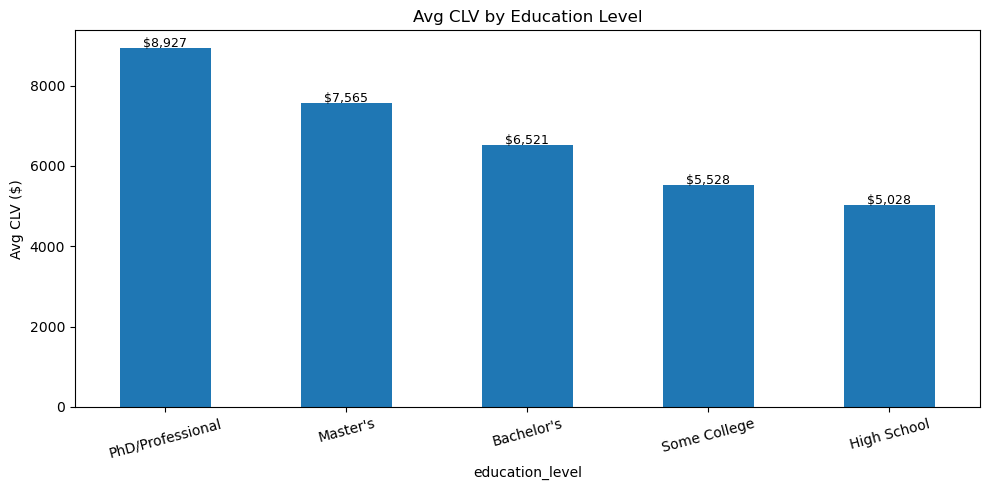

In [19]:
# CLV by education level
clv_edu = df.groupby('education_level')['customer_lifetime_value'].mean().sort_values(ascending=False)
print(clv_edu.round(0))

ax = clv_edu.plot(kind='bar', figsize=(10, 5))
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 30,
            f'${p.get_height():,.0f}', ha='center', fontsize=9)
plt.title('Avg CLV by Education Level')
plt.ylabel('Avg CLV ($)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

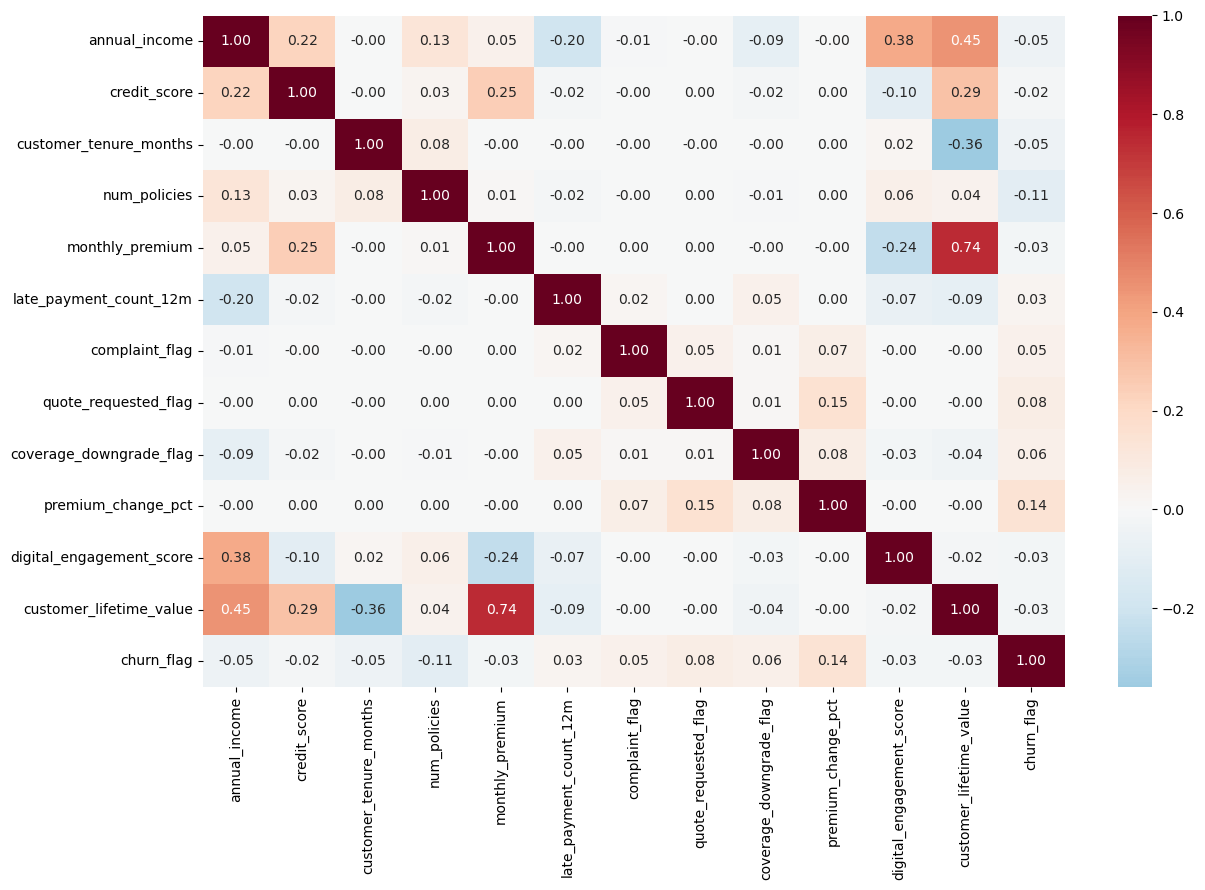

In [20]:
# CORRELATION HEATMAP
corr_cols = ['annual_income', 'credit_score', 'customer_tenure_months', 'num_policies', 'monthly_premium', 
             'late_payment_count_12m', 'complaint_flag', 'quote_requested_flag',
             'coverage_downgrade_flag', 'premium_change_pct', 'digital_engagement_score',
             'customer_lifetime_value', 'churn_flag']

corr = df[corr_cols].corr().round(2)

plt.figure(figsize=(13, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.tight_layout()
plt.show()

payment_frequency  Annual  Monthly  Quarterly
plan_tier                                    
Bronze               23.6     27.3       23.6
Gold                 21.3     24.5       21.7
Platinum             18.8     22.4       18.2
Silver               21.3     25.2       21.7


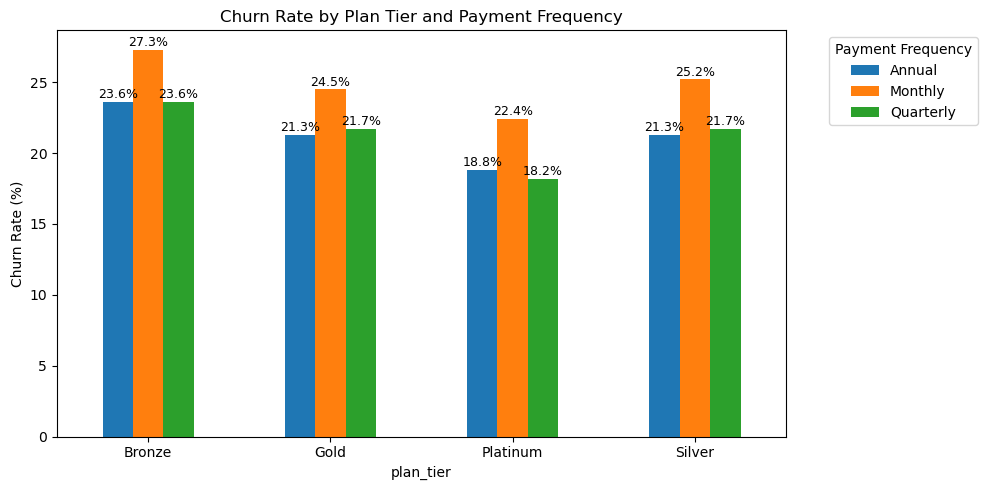

In [21]:
# Deep Dive 1: Plan Tier × Payment Frequency - Churn Rate
cross1 = df.groupby(['plan_tier','payment_frequency'])['churn_flag'].mean()*100
cross1 = cross1.unstack().round(1)
print(cross1)

ax = cross1.plot(kind='bar', figsize=(10,5))
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.05,
            f'{p.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
    
plt.title('Churn Rate by Plan Tier and Payment Frequency')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Payment Frequency', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

plan_tier          Bronze  Gold  Platinum  Silver
employment_status                                
Full-time            25.9  23.2      20.4    23.6
Part-time            26.5  23.5      22.2    25.0
Retired              23.8  21.3      20.9    22.2
Self-employed        25.3  22.6      20.1    22.7
Student              31.9  30.0      27.0    30.0
Unemployed           28.1  26.9      23.8    26.0


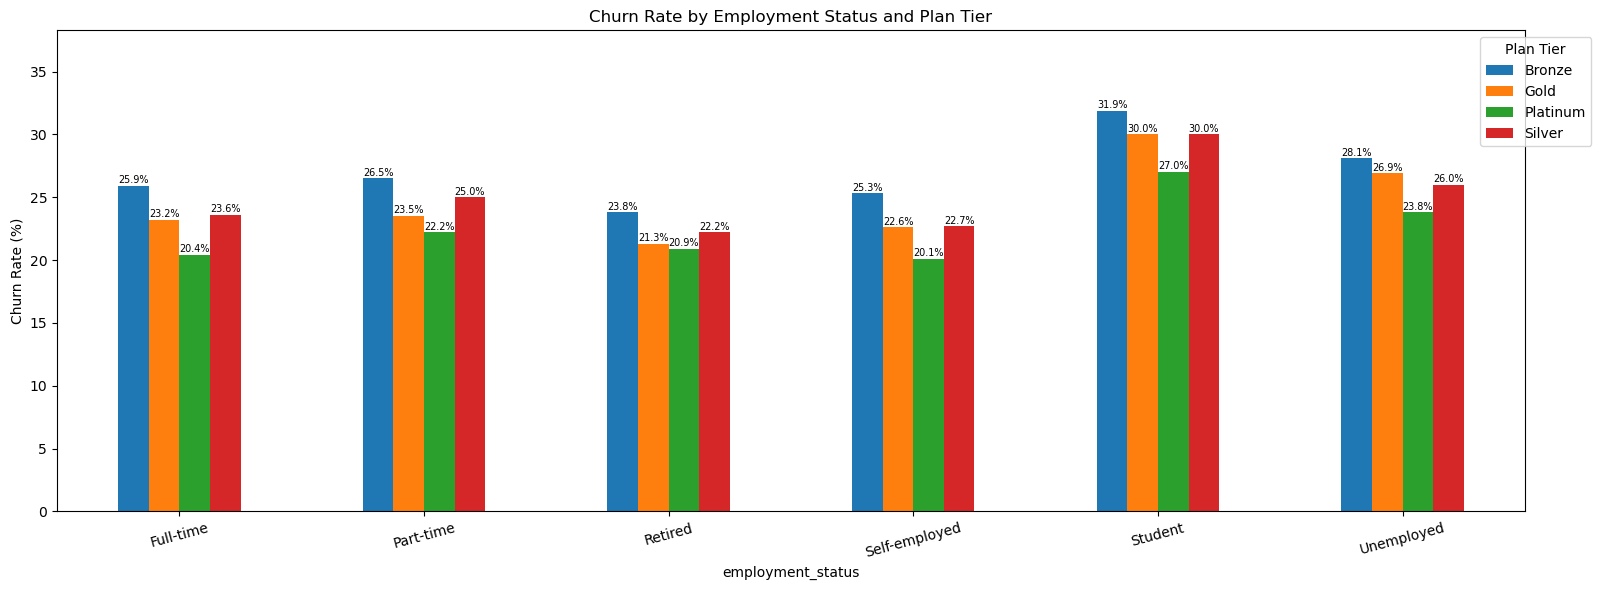

In [22]:
# Deep Dive 2: Employment Status × Plan Tier - Churn Rate
cross2 = df.groupby(['employment_status','plan_tier'])['churn_flag'].mean()*100
cross2 = cross2.unstack().round(1)
print(cross2)

ax = cross2.plot(kind='bar', figsize=(16,6))
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.05,
            f'{p.get_height():.1f}%', ha='center', va='bottom', fontsize=7)
    
plt.title('Churn Rate by Employment Status and Plan Tier')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=15)
plt.ylim(0, cross2.values.max() * 1.2)
plt.legend(title='Plan Tier', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Premium Change % by Plan Tier
plan_tier
Bronze      6.21
Gold        6.17
Platinum    6.20
Silver      6.20
Name: premium_change_pct, dtype: float64

Mean premium change % by plan tier and churn status:
           Retained  Churned
plan_tier                   
Bronze         5.53     8.15
Gold           5.55     8.17
Platinum       5.64     8.31
Silver         5.56     8.24


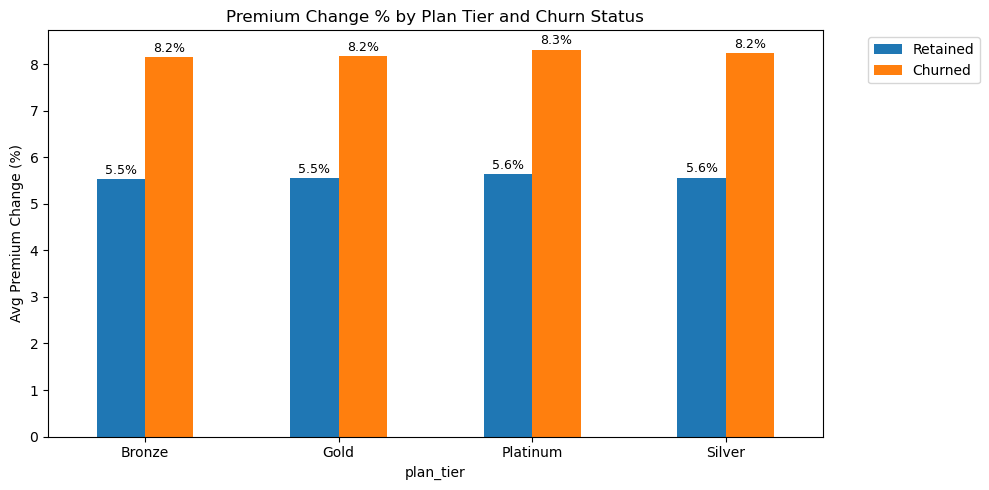

In [23]:
# Deep Dive Analysis 3: Premium Change % by Plan Tier and Churn Status
print("Premium Change % by Plan Tier")
prem = df.groupby('plan_tier')['premium_change_pct'].mean() * 100
print(prem.round(2))

# Also split by churn status within each plan tier
prem2 = df.groupby(['plan_tier', 'churn_flag'])['premium_change_pct'].mean() * 100
prem2 = prem2.unstack().round(2)
prem2.columns = ['Retained', 'Churned']
print("\nMean premium change % by plan tier and churn status:")
print(prem2)

ax = prem2.plot(kind='bar', figsize=(10, 5))
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.05,
            f'{p.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
    
plt.title('Premium Change % by Plan Tier and Churn Status')
plt.ylabel('Avg Premium Change (%)')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [24]:
# Deep Dive Analysis 4: Quote Requested Flag — Profile Analysis
print("Quote Requested Flag — Member Profile")
quote = df[df['quote_requested_flag'] == 1]
no_quote = df[df['quote_requested_flag'] == 0]

print(f"Members with quote requested : {len(quote):,} ({len(quote)/len(df)*100:.1f}%)")
print(f"Churn rate — quote requested : {quote['churn_flag'].mean()*100:.1f}%")
print(f"Churn rate — no quote        : {no_quote['churn_flag'].mean()*100:.1f}%")

# Profile: plan tier, employment, tenure
print("\nPlan tier breakdown — quote requested vs not:")
profile = df.groupby(['quote_requested_flag', 'plan_tier'])['churn_flag'].agg(['count', 'mean'])
profile['mean'] = (profile['mean'] * 100).round(1)
profile.columns = ['Count', 'Churn_%']
print(profile)

print("\nAvg tenure — quote requested vs not:")
print(df.groupby('quote_requested_flag')['customer_tenure_months'].mean().round(1))

print("\nEmployment status breakdown — quote requested:")
print(df[df['quote_requested_flag']==1]['employment_status'].value_counts(normalize=True).mul(100).round(1))

Quote Requested Flag — Member Profile
Members with quote requested : 55,793 (11.2%)
Churn rate — quote requested : 33.9%
Churn rate — no quote        : 22.9%

Plan tier breakdown — quote requested vs not:
                                 Count  Churn_%
quote_requested_flag plan_tier                 
0                    Bronze     149130     24.7
                     Gold        97307     22.1
                     Platinum    43815     19.8
                     Silver     153955     22.6
1                    Bronze      18740     36.2
                     Gold        12116     33.0
                     Platinum     5554     29.8
                     Silver      19383     33.5

Avg tenure — quote requested vs not:
quote_requested_flag
0    46.3
1    46.3
Name: customer_tenure_months, dtype: float64

Employment status breakdown — quote requested:
employment_status
Full-time        49.1
Retired          13.7
Self-employed    13.0
Part-time        11.9
Unemployed       10.7
Student        

Tenure Band × RFM Segment — Churn Rate
tenure_band           New (0-12m)  Early (13-36m)  Established (37-84m)  \
rfm_segment                                                               
At-Risk                      30.7            29.5                  27.3   
Champions                    19.8            18.3                  16.5   
Lost/Price-Sensitive         31.0            30.8                  29.2   
Loyal Customers              24.8            23.7                  21.3   
Potential Loyalists          28.4            27.6                  25.3   

tenure_band           Loyal (85-120m)  Champion (121-180m)  
rfm_segment                                                 
At-Risk                          26.4                 23.3  
Champions                        16.2                 14.6  
Lost/Price-Sensitive             26.8                 25.1  
Loyal Customers                  19.9                 18.2  
Potential Loyalists              23.4                 22.0  


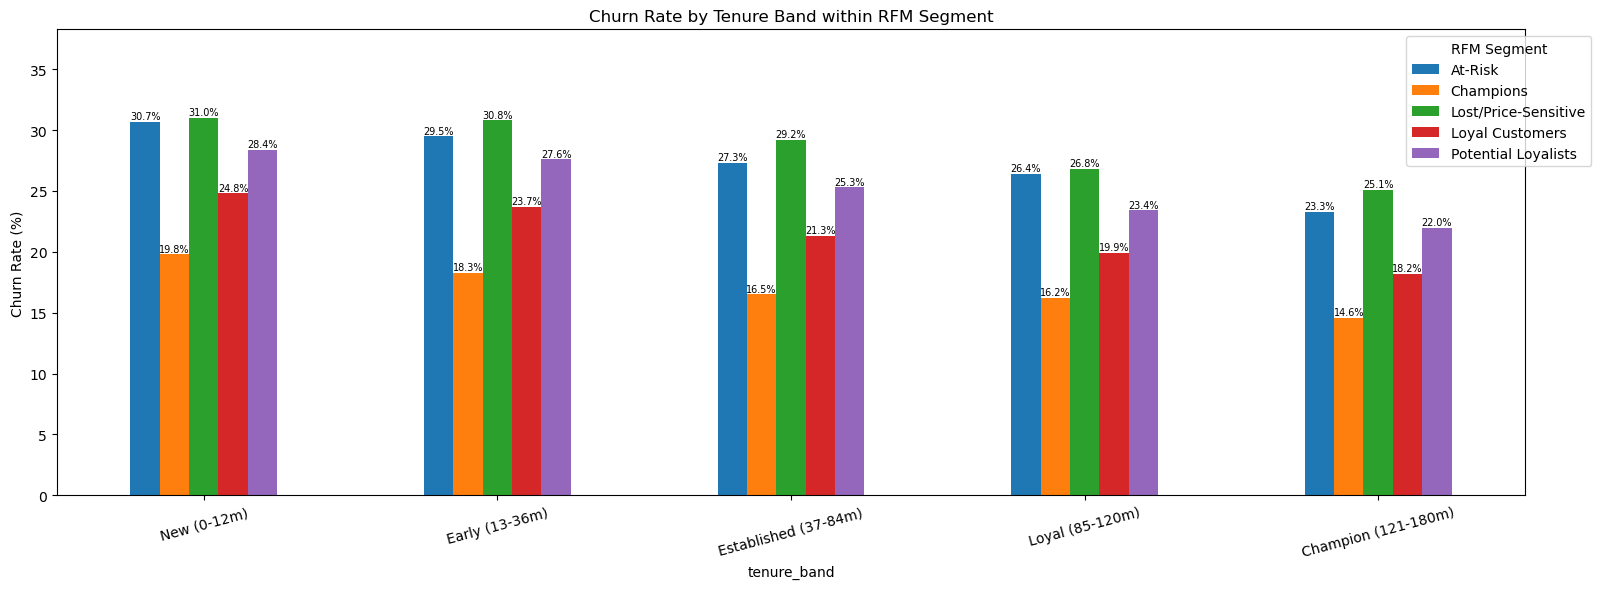


Age distribution within New (0-12m) band:
age_band
55-64    20.4
45-54    19.2
35-44    17.6
65-74    16.6
25-34    15.6
18-24     6.1
75+       4.5
Name: proportion, dtype: float64

Churn rate by age band within New (0-12m) band:
age_band
18-24    30.8
25-34    27.4
35-44    26.1
45-54    26.5
55-64    26.9
65-74    24.5
75+      24.7
Name: churn_flag, dtype: float64

Churn rate by age band overall (all tenures):
age_band
18-24    28.1
25-34    25.0
35-44    23.8
45-54    24.2
55-64    24.2
65-74    22.7
75+      22.5
Name: churn_flag, dtype: float64


In [25]:
# Deep Dive Analysis 5: Churn Rate by Tenure Band within RFM Segment
print("Tenure Band × RFM Segment — Churn Rate")

bands = [
    (1,   12,  'New (0-12m)'),
    (13,  36,  'Early (13-36m)'),
    (37,  84,  'Established (37-84m)'),
    (85,  120, 'Loyal (85-120m)'),
    (121, 180, 'Champion (121-180m)')
]

df['tenure_band'] = 'Unknown'
for lo, hi, label in bands:
    mask = (df['customer_tenure_months'] >= lo) & (df['customer_tenure_months'] <= hi)
    df.loc[mask, 'tenure_band'] = label

cross5 = df.groupby(['rfm_segment', 'tenure_band'])['churn_flag'].mean() * 100
cross5 = cross5.unstack().round(1)

# Reorder tenure columns
tenure_order = [b[2] for b in bands]
tenure_order = [t for t in tenure_order if t in cross5.columns]
cross5 = cross5[tenure_order]
print(cross5)

ax = cross5.T.plot(kind='bar', figsize=(16, 6))
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.05,
            f'{p.get_height():.1f}%', ha='center', va='bottom', fontsize=7)
    
plt.title('Churn Rate by Tenure Band within RFM Segment')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=15)
plt.ylim(0, cross2.values.max() * 1.2)
plt.legend(title='RFM Segment', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# Clean up temp column
df.drop(columns=['tenure_band'], inplace=True)

# Check age distibution within New band
print("\nAge distribution within New (0-12m) band:")
df['age_band'] = pd.cut(df['age'], bins=[17,24,34,44,54,64,74,90],
                         labels=['18-24','25-34','35-44','45-54','55-64','65-74','75+'])

new_members = df[df['customer_tenure_months'] <= 12]
print(new_members['age_band'].value_counts(normalize=True).mul(100).round(1))

print("\nChurn rate by age band within New (0-12m) band:")
print(new_members.groupby('age_band', observed=True)['churn_flag'].mean().mul(100).round(1))

print("\nChurn rate by age band overall (all tenures):")
print(df.groupby('age_band', observed=True)['churn_flag'].mean().mul(100).round(1))

df.drop(columns=['age_band'], inplace=True)

Behaviour Flags — Churn Rate and Profile
Churn rate by behaviour flag:
  autopay_enabled                Yes=21.6%  No=29.9%  Diff=-8.2pp
  complaint_flag                 Yes=33.4%  No=23.7%  Diff=+9.7pp
  quote_requested_flag           Yes=33.9%  No=22.9%  Diff=+11.0pp
  coverage_downgrade_flag        Yes=31.2%  No=23.3%  Diff=+7.8pp
  multi_policy_flag              Yes=15.2%  No=27.0%  Diff=-11.8pp

% of churned members with each flag set to 1:
  autopay_enabled                62.1%
  complaint_flag                 6.3%
  quote_requested_flag           15.7%
  coverage_downgrade_flag        13.6%
  multi_policy_flag              15.1%

Churned members with at least one risk flag: 31.1%
Retained members with at least one risk flag: 21.3%


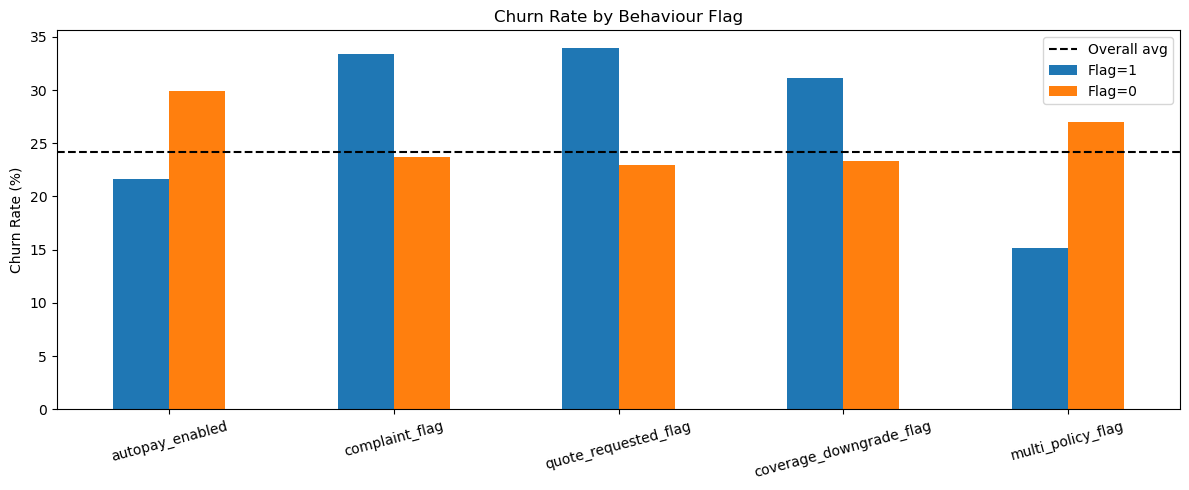

In [26]:
# Deep Dive Analysis 6: Behaviour Flags Analysis
print("Behaviour Flags — Churn Rate and Profile")

flag_cols = ['autopay_enabled', 'complaint_flag',
             'quote_requested_flag', 'coverage_downgrade_flag',
             'multi_policy_flag']

print("Churn rate by behaviour flag:")
for col in flag_cols:
    yes  = df[df[col]==1]['churn_flag'].mean()*100
    no   = df[df[col]==0]['churn_flag'].mean()*100
    diff = yes - no
    print(f"  {col:<30} Yes={yes:.1f}%  No={no:.1f}%  Diff={diff:+.1f}pp")

# How many churned members had at least one risk flag
risk_flags = ['complaint_flag','quote_requested_flag','coverage_downgrade_flag']
df['any_risk_flag'] = df[risk_flags].max(axis=1)

print("\n% of churned members with each flag set to 1:")
churned_df = df[df['churn_flag']==1]
for col in flag_cols:
    print(f"  {col:<30} {churned_df[col].mean()*100:.1f}%")

print(f"\nChurned members with at least one risk flag: "
      f"{churned_df['any_risk_flag'].mean()*100:.1f}%")
print(f"Retained members with at least one risk flag: "
      f"{df[df['churn_flag']==0]['any_risk_flag'].mean()*100:.1f}%")

flag_yes = [df[df[c]==1]['churn_flag'].mean()*100 for c in flag_cols]
flag_no  = [df[df[c]==0]['churn_flag'].mean()*100 for c in flag_cols]
flag_df  = pd.DataFrame({'Flag=1':flag_yes,'Flag=0':flag_no}, index=flag_cols)
flag_df.plot(kind='bar', figsize=(12,5)) 
plt.axhline(df['churn_flag'].mean()*100, color='black',
            linestyle='--', label='Overall avg')
plt.title('Churn Rate by Behaviour Flag')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

df.drop(columns=['any_risk_flag'], inplace=True)

plan_tier  Bronze  Gold  Platinum  Silver
age_band                                 
18-24        29.8  26.7      24.8    27.9
25-34        27.0  24.4      21.0    24.8
35-44        25.7  23.2      20.1    23.6
45-54        26.2  23.3      21.1    23.8
55-64        26.2  23.2      21.1    23.9
65-74        24.2  21.6      20.5    22.2
75+          23.8  22.1      19.7    22.0


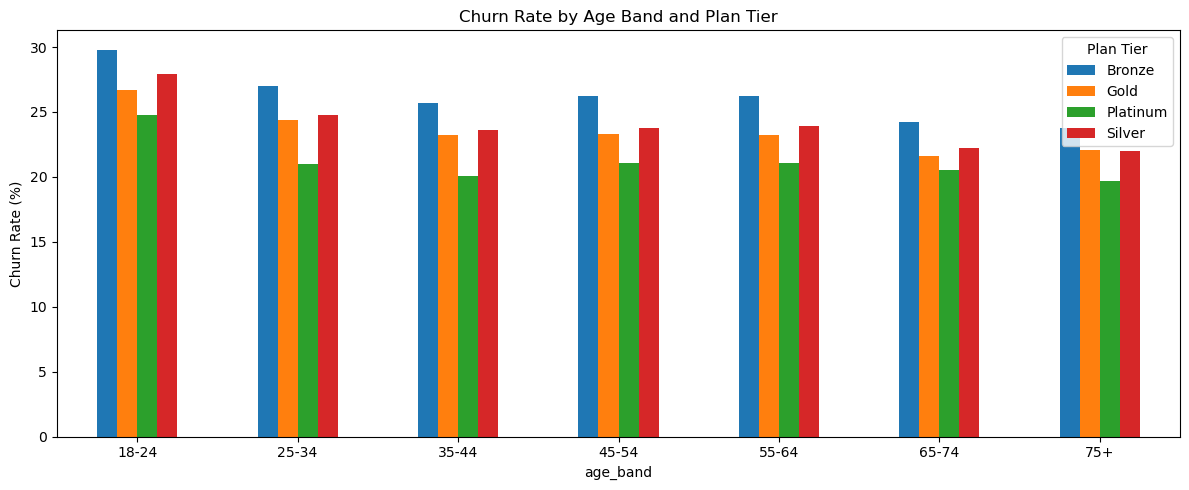

In [27]:
# Deep Dive 7: Age Band x Plan Tier
df['age_band'] = pd.cut(df['age'], bins=[17,24,34,44,54,64,74,90],
                         labels=['18-24','25-34','35-44','45-54','55-64','65-74','75+'])

cross7 = df.groupby(['age_band','plan_tier'], observed=True)['churn_flag'].mean()*100
cross7 = cross7.unstack().round(1)
print(cross7)

cross7.plot(kind='bar', figsize=(12,5))
plt.title('Churn Rate by Age Band and Plan Tier')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Plan Tier')
plt.tight_layout()
plt.show()

df.drop(columns=['age_band'], inplace=True)

NPS Score — Churn Rate and Member Profile
Churn rate by NPS group:
                  Count  Churn_%
nps_group                       
Detractor (0-4)    7173     34.5
No Response      337029     24.1
Passive (5-6)     51892     23.9
Promoter (7-10)  103906     23.7


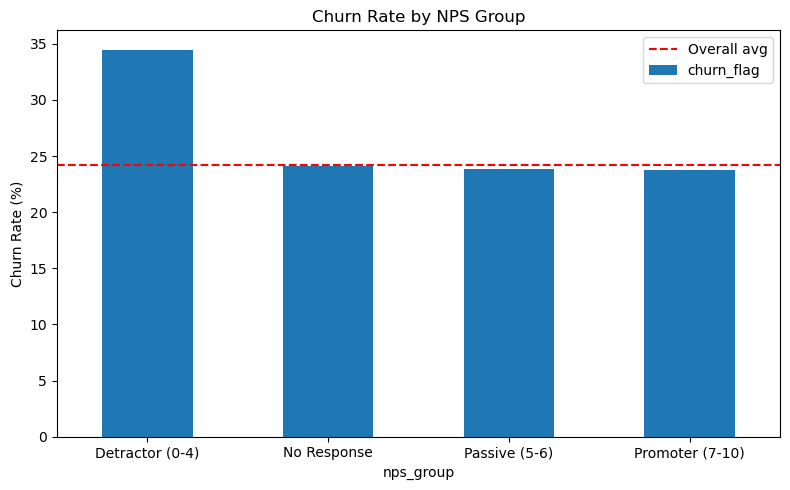


Detractor (0-4) profile vs overall:
  Count: 7,173 (1.4% of members)
  Churn rate: 34.5%

  Plan tier breakdown:
plan_tier
Bronze      35.0
Silver      35.0
Gold        20.8
Platinum     9.1
Name: proportion, dtype: float64

  Avg tenure: 45.8 months (vs overall 46.3)

  Complaint flag rate: 99.9% (vs overall 4.6%)
  Plan tier breakdown:
plan_tier
Bronze      35.0
Silver      35.0
Gold        20.8
Platinum     9.1
Name: proportion, dtype: float64


In [28]:
# Deep Dive 8: NPS Score Profile
print("NPS Score — Churn Rate and Member Profile")

# Convert NPS to numeric where possible, keep No Response separate
df['nps_numeric'] = pd.to_numeric(df['nps_score'], errors='coerce')

# Churn rate by NPS group
df['nps_group'] = 'No Response'
df.loc[df['nps_numeric'].between(0, 4),  'nps_group'] = 'Detractor (0-4)'
df.loc[df['nps_numeric'].between(5, 6),  'nps_group'] = 'Passive (5-6)'
df.loc[df['nps_numeric'].between(7, 10), 'nps_group'] = 'Promoter (7-10)'

print("Churn rate by NPS group:")
nps_summary = df.groupby('nps_group')['churn_flag'].agg(['count', 'mean'])
nps_summary['mean'] = (nps_summary['mean'] * 100).round(1)
nps_summary.columns = ['Count', 'Churn_%']
print(nps_summary)

# Plot
nps_churn = df.groupby('nps_group')['churn_flag'].mean() * 100
nps_churn.plot(kind='bar', figsize=(8, 5))
plt.axhline(df['churn_flag'].mean()*100, color='red',
            linestyle='--', label='Overall avg')
plt.title('Churn Rate by NPS Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

# Profile of Detractors (0-4)
print("\nDetractor (0-4) profile vs overall:")
det = df[df['nps_group'] == 'Detractor (0-4)']
print(f"  Count: {len(det):,} ({len(det)/len(df)*100:.1f}% of members)")
print(f"  Churn rate: {det['churn_flag'].mean()*100:.1f}%")
print(f"\n  Plan tier breakdown:")
print(det['plan_tier'].value_counts(normalize=True).mul(100).round(1))
print(f"\n  Avg tenure: {det['customer_tenure_months'].mean():.1f} months "
      f"(vs overall {df['customer_tenure_months'].mean():.1f})")
print(f"\n  Complaint flag rate: {det['complaint_flag'].mean()*100:.1f}% "
      f"(vs overall {df['complaint_flag'].mean()*100:.1f}%)")
print(f"  Plan tier breakdown:")
print(det['plan_tier'].value_counts(normalize=True).mul(100).round(1))

# Clean up
df.drop(columns=['nps_numeric', 'nps_group'], inplace=True)

## HYPOTHESIS TESTING

In [29]:
# Confirm df is loaded correctly before running tests
print(f'Rows: {len(df):,} | Churn rate: {df["churn_flag"].mean()*100:.1f}%')

Rows: 500,000 | Churn rate: 24.2%


#### H1 - Churn rate differs across plan tiers

In [30]:
ct1 = pd.crosstab(df['plan_tier'], df['churn_flag'])
chi2, p, dof, _ = chi2_contingency(ct1)
v = np.sqrt(chi2 / (ct1.values.sum() * (min(ct1.shape)-1)))
print(f'\nChi-Square: {chi2:.2f} | p-value: {p:.6f} | df: {dof} | Cramers V: {v:.4f}')


Chi-Square: 637.70 | p-value: 0.000000 | df: 3 | Cramers V: 0.0357


#### H2 — Monthly premium differs between churned and retained

In [31]:
churned  = df[df['churn_flag']==1]['monthly_premium']
retained = df[df['churn_flag']==0]['monthly_premium']

print(f'Churned  — Mean: ${churned.mean():.2f}')
print(f'Retained — Mean: ${retained.mean():.2f}')

t, p = ttest_ind(churned, retained, equal_var=False)
d = (churned.mean()-retained.mean()) / np.sqrt((churned.std()**2+retained.std()**2)/2)

print(f'\nt-stat: {t:.4f} | p-value: {p:.6f} | Cohens d: {d:.4f}')

Churned  — Mean: $1074.86
Retained — Mean: $1117.57

t-stat: -19.7363 | p-value: 0.000000 | Cohens d: -0.0649


#### H3 — CLV differs significantly across education levels

In [32]:
groups = [df[df['education_level']==e]['customer_lifetime_value'].dropna()
          for e in df['education_level'].dropna().unique()]
f, p = f_oneway(*groups)
ss_b = sum(len(g)*(g.mean()-df['customer_lifetime_value'].mean())**2 for g in groups)
ss_t = df['customer_lifetime_value'].dropna().var() * len(df['customer_lifetime_value'].dropna())
eta2 = ss_b / ss_t

print(f'\nF-stat: {f:.2f} | p-value: {p:.6f} | eta2: {eta2:.4f}')


F-stat: 13540.37 | p-value: 0.000000 | eta2: 0.0977


#### H4 — Churn rate differs across payment frequencies

In [33]:
ct4 = pd.crosstab(df['payment_frequency'], df['churn_flag'])
chi2, p, dof, _ = chi2_contingency(ct4)
v = np.sqrt(chi2 / (ct4.values.sum() * (min(ct4.shape)-1)))

print(f'\nChi-Square: {chi2:.2f} | p-value: {p:.6f} | df: {dof} | Cramers V: {v:.4f}')


Chi-Square: 832.83 | p-value: 0.000000 | df: 2 | Cramers V: 0.0408


#### H5 — Premium change % is higher for churned members

In [34]:
churned  = df[df['churn_flag']==1]['premium_change_pct']
retained = df[df['churn_flag']==0]['premium_change_pct']

print(f'Churned  — Mean: {churned.mean()*100:.2f}%')
print(f'Retained — Mean: {retained.mean()*100:.2f}%')

t, p = ttest_ind(churned, retained, equal_var=False)
d = (churned.mean()-retained.mean()) / np.sqrt((churned.std()**2+retained.std()**2)/2)

print(f'\nt-stat: {t:.4f} | p-value: {p:.6f} | Cohens d: {d:.4f}')

Churned  — Mean: 8.20%
Retained — Mean: 5.56%

t-stat: 97.5173 | p-value: 0.000000 | Cohens d: 0.3287


#### H6 - Churn rate differs significantly across age bands

In [35]:
df['age_band'] = pd.cut(df['age'], bins=[17,24,34,44,54,64,74,90],
                         labels=['18-24','25-34','35-44','45-54','55-64','65-74','75+'])

ct6 = pd.crosstab(df['age_band'], df['churn_flag'])
chi2, p, dof, _ = chi2_contingency(ct6)
v = np.sqrt(chi2 / (ct6.values.sum() * (min(ct6.shape)-1)))

print(f'\nChi-Square: {chi2:.2f} | p-value: {p:.6f} | df: {dof} | Cramers V: {v:.4f}')


Chi-Square: 414.58 | p-value: 0.000000 | df: 6 | Cramers V: 0.0288


#### H7 - Churn rate is significantly lower for multi-policy members than single-policy members

In [36]:
ct7 = pd.crosstab(df['multi_policy_flag'], df['churn_flag'])
chi2, p, dof, _ = chi2_contingency(ct7)
v = np.sqrt(chi2 / (ct7.values.sum() * (min(ct7.shape)-1)))

print(f'\nChi-Square: {chi2:.2f} | p-value: {p:.6f} | df: {dof} | Cramers V: {v:.4f}')


Chi-Square: 6981.78 | p-value: 0.000000 | df: 1 | Cramers V: 0.1182


## RFM SEGMENTATION & FACTOR ANALYSIS

In [37]:
# RFM columns already exist in dataset — just summarise
seg_stats = df.groupby('rfm_segment').agg(
    Count=('customer_id', 'count'),
    Churn_Rate=('churn_flag', 'mean'),
    Avg_CLV=('customer_lifetime_value', 'mean'),
    Avg_Premium=('net_monthly_premium', 'mean')
).round(2)
seg_stats['Churn_%'] = (seg_stats['Churn_Rate'] * 100).round(1)
print(seg_stats.drop('Churn_Rate', axis=1).sort_values('Churn_%'))

                       Count  Avg_CLV  Avg_Premium  Churn_%
rfm_segment                                                
Champions              68865  9028.38      1067.29     17.0
Loyal Customers       168046  7118.91       829.71     22.0
Potential Loyalists   193125  5381.11       623.48     26.0
At-Risk                47420  3995.54       461.83     28.0
Lost/Price-Sensitive   22544  3097.49       357.80     30.0


In [38]:
# Factor Analysis (PCA)
fa_cols = ['monthly_premium', 'annual_income', 'deductible', 'out_of_pocket_max',
           'coverage_amount', 'num_policies', 'customer_tenure_months',
           'late_payment_count_12m', 'digital_engagement_score', 'num_claims_12m',
           'total_claim_amount_12m', 'rx_monthly_cost', 'loss_ratio_12m',
           'credit_score', 'net_monthly_premium']

X_sc = StandardScaler().fit_transform(df[fa_cols].dropna())

pca = PCA(n_components=8)
pca.fit(X_sc)

explained    = pca.explained_variance_ratio_ * 100
cumulative   = np.cumsum(explained)
eigenvalues  = pca.explained_variance_

print(f'{"Factor":<10} {"Eigenvalue":<14} {"Variance %":<14} {"Cumulative %"}')
for i, (e, ev) in enumerate(zip(explained, eigenvalues)):
    print(f'Factor {i+1:<4} {ev:<14.3f} {e:<14.2f} {cumulative[i]:.2f}')

Factor     Eigenvalue     Variance %     Cumulative %
Factor 1    3.248          21.66          21.66
Factor 2    1.972          13.15          34.80
Factor 3    1.607          10.71          45.51
Factor 4    1.477          9.84           55.36
Factor 5    1.061          7.07           62.43
Factor 6    0.977          6.52           68.95
Factor 7    0.943          6.29           75.23
Factor 8    0.892          5.95           81.18


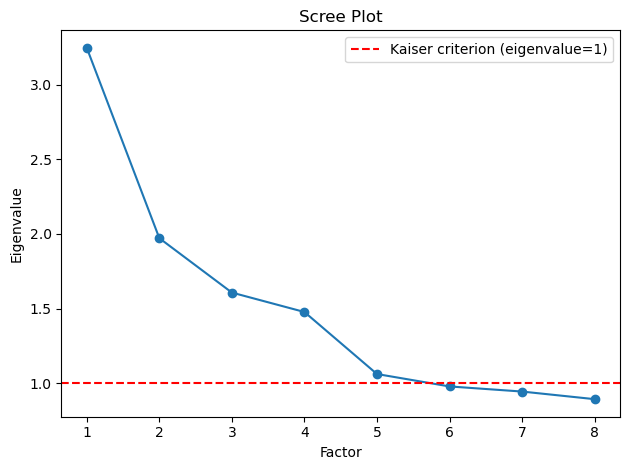

In [39]:
# Scree Plot
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, 'o-')
plt.axhline(y=1, color='red', linestyle='--', label='Kaiser criterion (eigenvalue=1)')
plt.title('Scree Plot')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.legend()
plt.tight_layout()
plt.show()

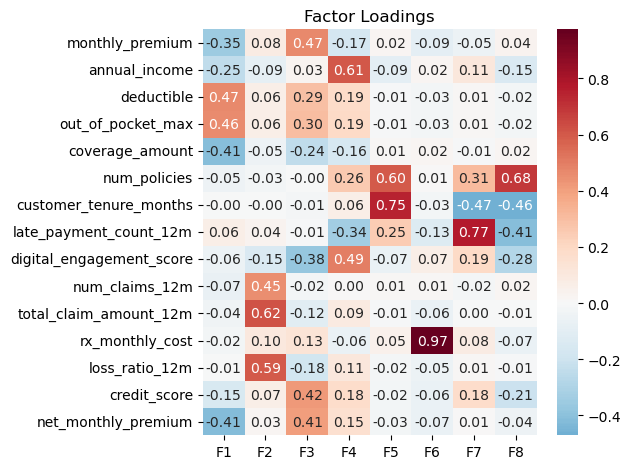

F1: ['deductible', 'out_of_pocket_max', 'net_monthly_premium']
F2: ['total_claim_amount_12m', 'loss_ratio_12m', 'num_claims_12m']
F3: ['monthly_premium', 'credit_score', 'net_monthly_premium']
F4: ['annual_income', 'digital_engagement_score', 'late_payment_count_12m']
F5: ['customer_tenure_months', 'num_policies', 'late_payment_count_12m']


In [40]:
# Factor Loading Heatmap
loadings = pd.DataFrame(pca.components_.T, index=fa_cols,
                        columns=[f'F{i+1}' for i in range(8)]).round(3)

sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Factor Loadings')
plt.tight_layout()
plt.show()

# Top 3 variables per factor
for col in [f'F{i+1}' for i in range(5)]:
    top3 = loadings[col].abs().nlargest(3).index.tolist()
    print(f'{col}: {top3}')

## CHURN CLASSIFICATION MODEL

In [41]:
# FEATURE ENGINEERING & TRAIN/TEST SPLIT
# Encode categorical columns
# Use a sample of 100,000 rows to keep training time manageable
df_sample = df.sample(n=100_000, random_state=42)

for col in ['plan_tier', 'payment_frequency', 'us_region', 'employment_status',
            'policy_type', 'network_type', 'education_level', 'rfm_segment']:
    if col in df_sample.columns:
        df_sample = pd.get_dummies(df_sample, columns=[col], drop_first=False)

# Add age_band - confirmed as independent churn driver in EDA and H6
df_sample['age_band'] = pd.cut(df_sample['age'],
                                bins=[17,24,34,44,54,64,74,90],
                                labels=['18-24','25-34','35-44',
                                        '45-54','55-64','65-74','75+'])
df_sample = pd.get_dummies(df_sample, columns=['age_band'], drop_first=False)

drop_cols = ['customer_id', 'as_of_date', 'policy_start_date', 'renewal_date',
             'state', 'churn_flag', 'churn_type', 'nps_score', 'rfm_score']

feature_cols = [c for c in df_sample.columns
                if c not in drop_cols
                and df_sample[c].dtype in ['int64', 'float64', 'uint8', 'bool']]

X = df_sample[feature_cols].fillna(0)
y = df_sample['churn_flag'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,} | Features: {len(feature_cols)}')
print(f'Churn rate in sample: {y.mean()*100:.1f}%')

Train: 80,000 | Test: 20,000 | Features: 76
Churn rate in sample: 24.1%


In [42]:
# Train all models
models = {
    'Logistic Regression': (LogisticRegression(class_weight='balanced',
                             max_iter=200, random_state=42), X_train_sc, X_test_sc),
    'Random Forest':       (RandomForestClassifier(n_estimators=50,
                             max_depth=8, random_state=42, n_jobs=-1), X_train, X_test),
    'Gradient Boosting':   (GradientBoostingClassifier(n_estimators=50,
                             learning_rate=0.1, max_depth=4, random_state=42), X_train, X_test),
}
if HAS_XGB:
    models['XGBoost'] = (XGBClassifier(n_estimators=50, learning_rate=0.1,
                          max_depth=4, random_state=42,
                          eval_metric='logloss', verbosity=0), X_train, X_test)

results = {}
for name, (model, Xtr, Xte) in models.items():
    model.fit(Xtr, y_train)
    yp    = model.predict(Xte)
    yprob = model.predict_proba(Xte)[:, 1]
    results[name] = {
        'model': model,
        'yp':    yp,
        'yprob': yprob,
        'acc':   accuracy_score(y_test, yp),
        'f1':    f1_score(y_test, yp),
        'auc':   roc_auc_score(y_test, yprob)
    }
    print(f'{name:<25} Acc={results[name]["acc"]:.3f}  '
          f'F1={results[name]["f1"]:.3f}  AUC={results[name]["auc"]:.3f}')

print(f'\nresults populated: {list(results.keys())}')

Logistic Regression       Acc=0.609  F1=0.429  AUC=0.652
Random Forest             Acc=0.759  F1=0.001  AUC=0.657
Gradient Boosting         Acc=0.760  F1=0.084  AUC=0.662
XGBoost                   Acc=0.760  F1=0.075  AUC=0.663

results populated: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']


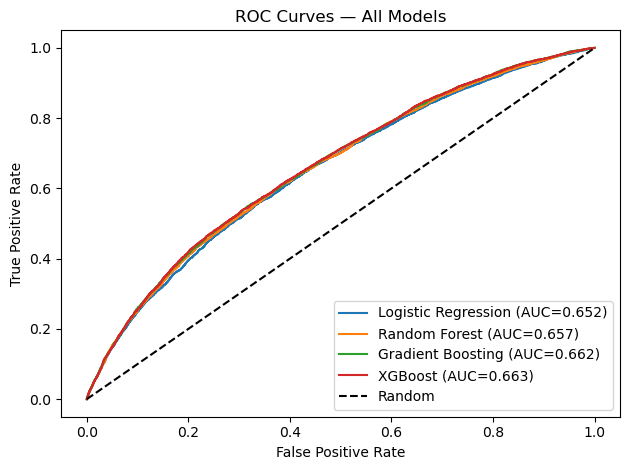

In [43]:
# ROC Curve
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['yprob'])
    plt.plot(fpr, tpr, label=f'{name} (AUC={res["auc"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
# Best Model Report
best_name = max(results, key=lambda n: results[n]['auc'])
best      = results[best_name]

print(f'Best Model: {best_name}  AUC={best["auc"]:.3f}')
print()
print(classification_report(y_test, best['yp'], target_names=['Retained', 'Churned']))

Best Model: XGBoost  AUC=0.663

              precision    recall  f1-score   support

    Retained       0.76      0.99      0.86     15177
     Churned       0.52      0.04      0.08      4823

    accuracy                           0.76     20000
   macro avg       0.64      0.51      0.47     20000
weighted avg       0.71      0.76      0.67     20000



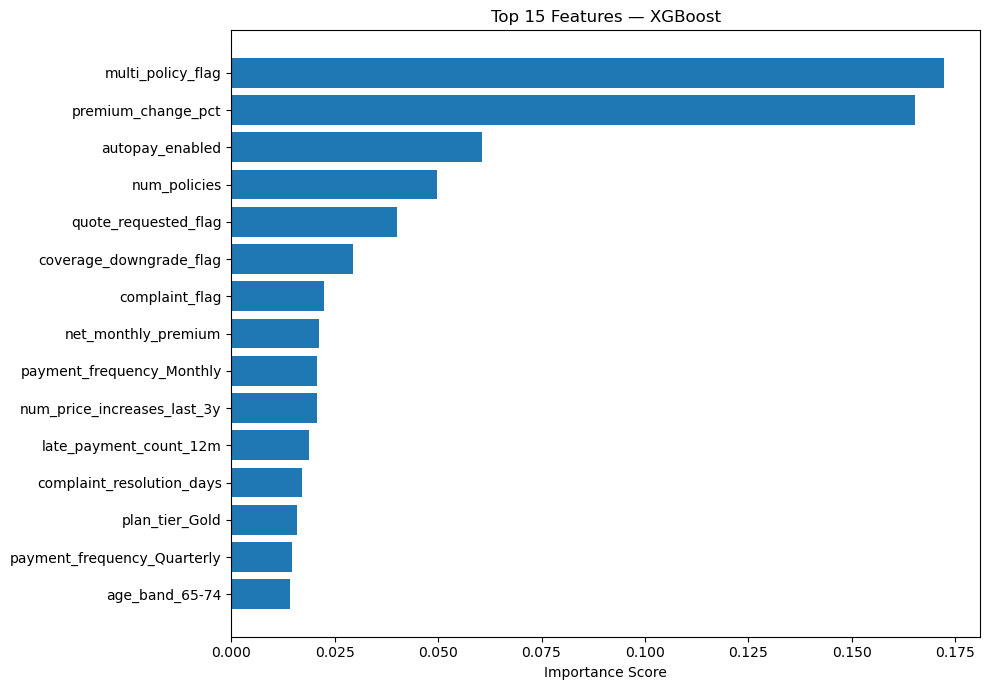


Top 10 features:
                    Feature  Importance
          multi_policy_flag    0.172390
         premium_change_pct    0.165355
            autopay_enabled    0.060554
               num_policies    0.049772
       quote_requested_flag    0.040008
    coverage_downgrade_flag    0.029505
             complaint_flag    0.022366
        net_monthly_premium    0.021188
  payment_frequency_Monthly    0.020611
num_price_increases_last_3y    0.020602


In [45]:
# Feature Importance
model = best['model']

if hasattr(model, 'feature_importances_'):
    imps = model.feature_importances_
elif hasattr(model, 'coef_'):
    imps = np.abs(model.coef_[0])

feat_df = (pd.DataFrame({'Feature': feature_cols, 'Importance': imps})
             .nlargest(15, 'Importance'))

plt.figure(figsize=(10, 7))
plt.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1])
plt.title(f'Top 15 Features — {best_name}')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(feat_df.head(10)[['Feature', 'Importance']].to_string(index=False))

## CUSTOMER LIFETIME VALUE (CLV) REGRESSION

In [46]:
# Feature Preparation
df_r = df.copy()
for col in ['plan_tier', 'payment_frequency', 'us_region', 'employment_status',
            'policy_type', 'network_type', 'education_level']:
    if col in df_r.columns:
        df_r = pd.get_dummies(df_r, columns=[col], drop_first=True)

# Add age_band
df_r['age_band'] = pd.cut(df_r['age'], bins=[17,24,34,44,54,64,74,90],
                           labels=['18-24','25-34','35-44',
                                   '45-54','55-64','65-74','75+'])
df_r = pd.get_dummies(df_r, columns=['age_band'], drop_first=True)

# monthly_premium is excluded — it is highly correlated with CLV (r=0.74)
# identified as multicollinear in EDA notebook
reg_features = ['annual_income', 'age', 'credit_score', 'customer_tenure_months',
                'num_policies', 'deductible', 'out_of_pocket_max',
                'subsidy_amount_monthly', 'num_claims_12m', 'total_claim_amount_12m',
                'late_payment_count_12m', 'digital_engagement_score', 'churn_flag']
reg_features += [c for c in df_r.columns if any(c.startswith(p) for p in
                 ['plan_tier_', 'employment_status_', 'education_level_', 'us_region_'])]
reg_features += [c for c in df_r.columns if c.startswith('age_band_')]
reg_features  = [f for f in reg_features if f in df_r.columns]

X = df_r[reg_features].fillna(0).astype(float)
y = df_r['customer_lifetime_value'].astype(float)

print(f'Features: {len(reg_features)} | Rows: {len(X):,}')
print(f'CLV mean: ${y.mean():,.0f} | range: ${y.min():,.0f}–${y.max():,.0f}')

Features: 34 | Rows: 500,000
CLV mean: $6,233 | range: $500–$48,575


In [47]:
# Train & Evaluate
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv = cross_val_score(LinearRegression(), X, y, cv=kf, scoring='r2')

print(f'R²       : {r2:.4f}')
print(f'MAE      : ${mae:,.2f}')
print(f'RMSE     : ${rmse:,.2f}')
print(f'5-Fold CV: {cv.mean():.4f} ± {cv.std():.4f}')

R²       : 0.7285
MAE      : $1,123.48
RMSE     : $1,813.79
5-Fold CV: 0.7312 ± 0.0028


In [48]:
# Coefficients
coef_df = (pd.DataFrame({'Feature': reg_features, 'Coefficient': model.coef_})
             .sort_values('Coefficient', ascending=False))

print('Top 10 CLV drivers:')
print(coef_df.head(10).to_string(index=False))
print('\nBottom 5 (decreases CLV):')
print(coef_df.tail(5).to_string(index=False))

Top 10 CLV drivers:
                  Feature  Coefficient
       plan_tier_Platinum  1930.108260
           plan_tier_Gold   997.163686
      us_region_Northeast   894.735800
employment_status_Student   892.332502
           age_band_45-54   809.661758
           age_band_55-64   723.187688
           us_region_West   709.281573
           age_band_35-44   652.509386
         plan_tier_Silver   344.205158
           age_band_25-34   304.879371

Bottom 5 (decreases CLV):
                     Feature  Coefficient
      late_payment_count_12m   -48.952824
education_level_Some College  -213.952845
   employment_status_Retired  -260.218737
 education_level_High School  -368.316048
employment_status_Unemployed  -472.253249


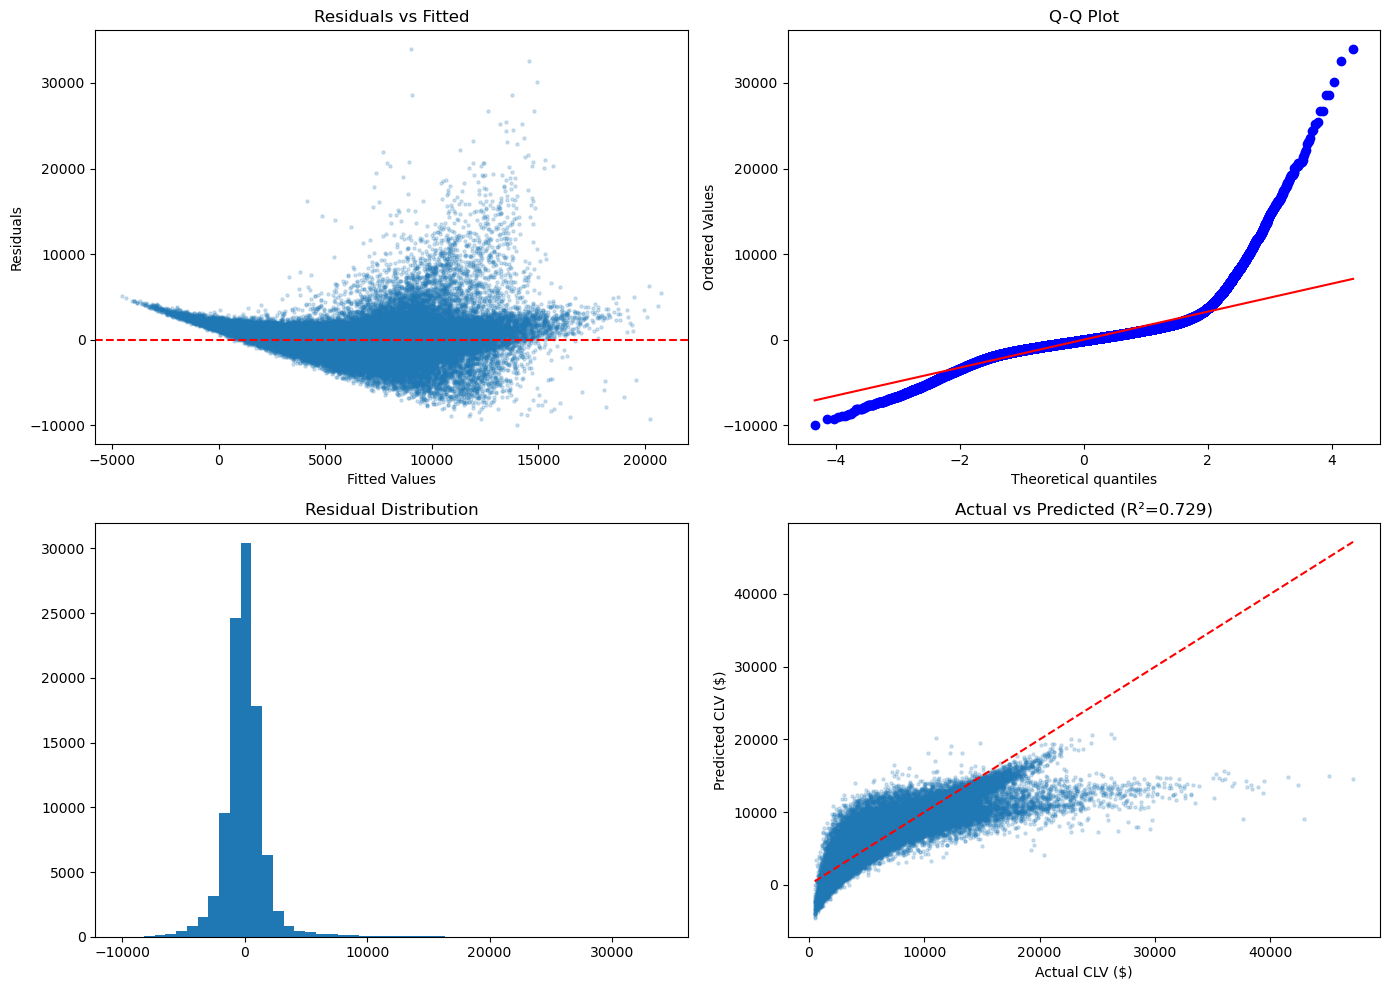

In [49]:
# Diagnostic Plots
residuals = y_test.values - y_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals vs Fitted
axes[0, 0].scatter(y_pred, residuals, alpha=0.2, s=5)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Residuals vs Fitted')
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')

# Q-Q Plot
from scipy.stats import probplot
probplot(residuals, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot')

# Residual distribution
axes[1, 0].hist(residuals, bins=50)
axes[1, 0].set_title('Residual Distribution')

# Actual vs Predicted
axes[1, 1].scatter(y_test, y_pred, alpha=0.2, s=5)
axes[1, 1].plot([y_test.min(), y_test.max()],
                [y_test.min(), y_test.max()], 'r--')
axes[1, 1].set_title(f'Actual vs Predicted (R²={r2:.3f})')
axes[1, 1].set_xlabel('Actual CLV ($)')
axes[1, 1].set_ylabel('Predicted CLV ($)')

plt.tight_layout()
plt.show()

## TIME SERIES FORECASTING

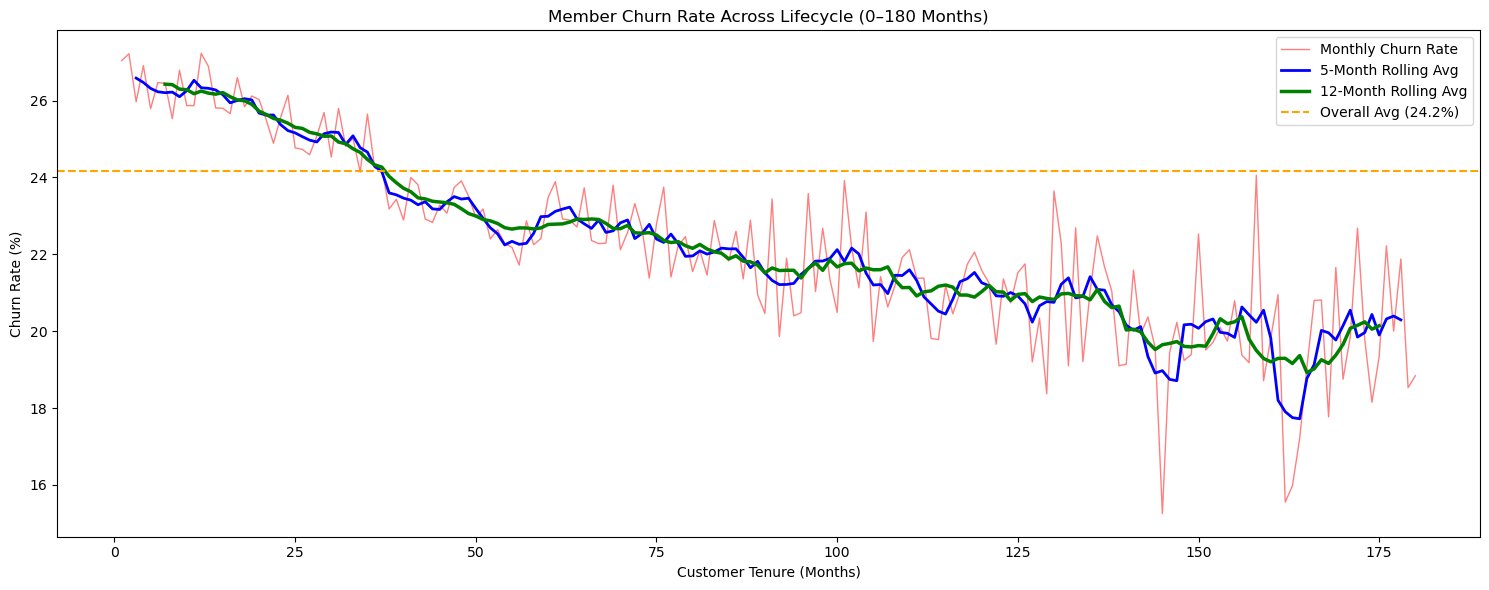

In [50]:
# Lifecycle Churn Curve
lifecycle = df.groupby('customer_tenure_months').agg(
    Total=('churn_flag', 'count'),
    Churned=('churn_flag', 'sum')
).reset_index()
lifecycle['Churn_Rate'] = (lifecycle['Churned'] / lifecycle['Total'] * 100).round(2)
lifecycle['Rolling_5']  = lifecycle['Churn_Rate'].rolling(window=5,  center=True).mean()
lifecycle['Rolling_12'] = lifecycle['Churn_Rate'].rolling(window=12, center=True).mean()

plt.figure(figsize=(15, 6))
plt.plot(lifecycle['customer_tenure_months'], lifecycle['Churn_Rate'],
         'r-', linewidth=1, alpha=0.5, label='Monthly Churn Rate')
plt.plot(lifecycle['customer_tenure_months'], lifecycle['Rolling_5'],
         'b-', linewidth=2, label='5-Month Rolling Avg')
plt.plot(lifecycle['customer_tenure_months'], lifecycle['Rolling_12'],
         'g-', linewidth=2.5, label='12-Month Rolling Avg')
plt.axhline(df['churn_flag'].mean()*100, color='orange', linestyle='--',
            label=f'Overall Avg ({df["churn_flag"].mean()*100:.1f}%)')
plt.title('Member Churn Rate Across Lifecycle (0–180 Months)')
plt.xlabel('Customer Tenure (Months)')
plt.ylabel('Churn Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

In [51]:
# Tenure Band Analysis
bands = [
    (1,   12,  'New (0-12m)'),
    (13,  36,  'Early (13-36m)'),
    (37,  84,  'Established (37-84m)'),
    (85,  120, 'Loyal (85-120m)'),
    (121, 180, 'Champion (121-180m)')
]

band_df = []
for lo, hi, label in bands:
    sub = df[(df['customer_tenure_months'] >= lo) & (df['customer_tenure_months'] <= hi)]
    band_df.append({
        'Band':       label,
        'Count':      len(sub),
        'Churn_Rate': sub['churn_flag'].mean() * 100,
        'Avg_CLV':    sub['customer_lifetime_value'].mean()
    })
band_df = pd.DataFrame(band_df)
print(band_df.to_string(index=False))

                Band  Count  Churn_Rate     Avg_CLV
         New (0-12m) 118580   26.490977 7316.577861
      Early (13-36m) 150688   25.483781 6879.875610
Established (37-84m) 146241   22.919701 6010.461979
     Loyal (85-120m)  44579   21.516858 4754.051998
 Champion (121-180m)  39912   19.826117 3040.371165


In [52]:
# Stationarity Test
try:
    from statsmodels.tsa.stattools import adfuller
    ts = lifecycle.set_index('customer_tenure_months')['Churn_Rate'].dropna()
    adf = adfuller(ts)
    print(f'ADF Test: stat={adf[0]:.4f}  p={adf[1]:.4f}')
    print(f'Stationary: {"Yes" if adf[1] < 0.05 else "No — needs differencing"}')
except ImportError:
    from scipy import stats as sp
    ts_vals = lifecycle['Churn_Rate'].dropna().values
    slope, intercept, r, p, _ = sp.linregress(np.arange(len(ts_vals)), ts_vals)
    print(f'Linear trend: slope={slope:.5f}%/month  p={p:.6f}')
    print(f'Direction: {"Decreasing" if slope < 0 else "Increasing"} churn over tenure')
    print(f'Correlation r={r:.4f}')

ADF Test: stat=-2.0710  p=0.2563
Stationary: No — needs differencing


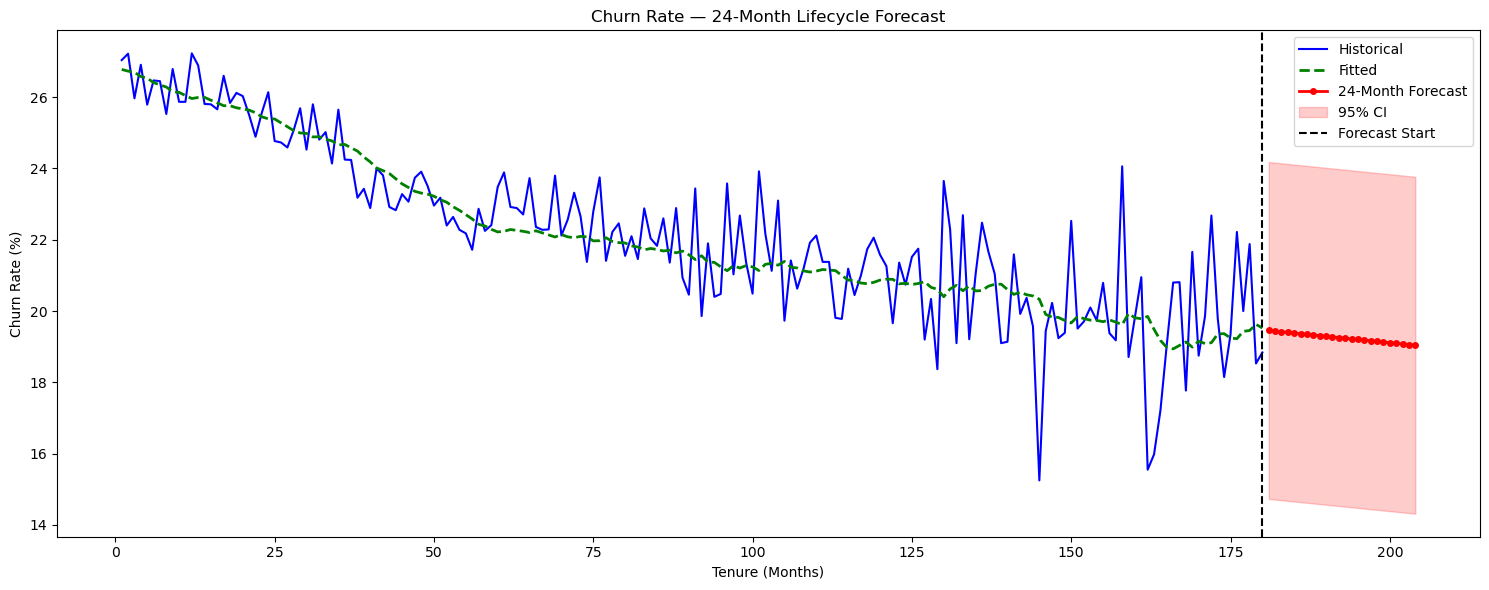

24-Month Forecast:
  Month 181: 19.46%  [14.73%–24.18%]
  Month 182: 19.44%  [14.71%–24.16%]
  Month 183: 19.42%  [14.69%–24.15%]
  Month 184: 19.40%  [14.68%–24.13%]
  Month 185: 19.38%  [14.66%–24.11%]
  Month 186: 19.37%  [14.64%–24.09%]
  Month 187: 19.35%  [14.62%–24.07%]
  Month 188: 19.33%  [14.60%–24.06%]
  Month 189: 19.31%  [14.59%–24.04%]
  Month 190: 19.29%  [14.57%–24.02%]
  Month 191: 19.28%  [14.55%–24.00%]
  Month 192: 19.26%  [14.53%–23.98%]
  Month 193: 19.24%  [14.51%–23.97%]
  Month 194: 19.22%  [14.50%–23.95%]
  Month 195: 19.20%  [14.48%–23.93%]
  Month 196: 19.19%  [14.46%–23.91%]
  Month 197: 19.17%  [14.44%–23.89%]
  Month 198: 19.15%  [14.42%–23.88%]
  Month 199: 19.13%  [14.41%–23.86%]
  Month 200: 19.11%  [14.39%–23.84%]
  Month 201: 19.10%  [14.37%–23.82%]
  Month 202: 19.08%  [14.35%–23.80%]
  Month 203: 19.06%  [14.33%–23.79%]
  Month 204: 19.04%  [14.32%–23.77%]


In [53]:
import warnings
from statsmodels.tools.sm_exceptions import ValueWarning
warnings.filterwarnings('ignore', category=ValueWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Forecast
try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    ts = lifecycle.set_index('customer_tenure_months')['Churn_Rate'].dropna()
    fit = ExponentialSmoothing(ts, trend='add', seasonal=None).fit(optimized=True)
    forecast    = fit.forecast(24)
    ci          = ts.std() * 1.96
    forecast_x  = np.arange(len(ts)+1, len(ts)+25)

    plt.figure(figsize=(15, 6))
    plt.plot(ts.index, ts.values, 'b-', linewidth=1.5, label='Historical')
    plt.plot(ts.index, fit.fittedvalues, 'g--', linewidth=2, label='Fitted')
    plt.plot(forecast_x, forecast.values, 'r-o', markersize=4,
             linewidth=2, label='24-Month Forecast')
    plt.fill_between(forecast_x, forecast.values - ci,
                     forecast.values + ci, alpha=0.2, color='red', label='95% CI')
    plt.axvline(len(ts), color='black', linestyle='--', label='Forecast Start')
    plt.title('Churn Rate — 24-Month Lifecycle Forecast')
    plt.xlabel('Tenure (Months)')
    plt.ylabel('Churn Rate (%)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print('24-Month Forecast:')
    for i, val in enumerate(forecast.values, 1):
        print(f'  Month {len(ts)+i}: {max(0,val):.2f}%  '
              f'[{max(0,val-ci):.2f}%–{val+ci:.2f}%]')

except ImportError:
    # Fallback — linear trend forecast
    ts_vals    = lifecycle['Churn_Rate'].dropna().values
    x          = np.arange(len(ts_vals))
    slope, intercept, r, p, _ = stats.linregress(x, ts_vals)
    future_x   = np.arange(len(ts_vals), len(ts_vals)+24)
    forecast   = intercept + slope * future_x
    ci         = (ts_vals - (intercept + slope*x)).std() * 1.96

    plt.figure(figsize=(15, 6))
    plt.plot(x, ts_vals, 'b-', linewidth=1.5, label='Historical')
    plt.plot(future_x, forecast, 'r-o', markersize=4,
             linewidth=2, label='24-Month Forecast')
    plt.fill_between(future_x, forecast-ci, forecast+ci,
                     alpha=0.2, color='red', label='95% CI')
    plt.axvline(len(ts_vals), color='black', linestyle='--', label='Forecast Start')
    plt.title('Churn Rate — 24-Month Lifecycle Forecast (Linear Trend)')
    plt.xlabel('Tenure (Months)')
    plt.ylabel('Churn Rate (%)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f'Linear trend: {slope:.5f}%/month  (r={r:.3f}  p={p:.6f})')
    print('24-Month Forecast:')
    for i, val in enumerate(forecast[:12], 1):
        print(f'  Month {len(ts_vals)+i}: {max(0,val):.2f}%  '
              f'[{max(0,val-ci):.2f}%–{val+ci:.2f}%]')